# Modularity Maximization vs. Stochastic Block Model on the Left oviIN Inputs (V3)

### Dataset: FAFB FlyWire v783

This notebook asks: **does the community structure in the oviIN input subconnectome depend on the method used to detect it?** Two independent methods — one based on modularity optimization (RenEEL) and one based on statistical inference (degree-corrected SBM) — are applied to the same network. If they find the same communities, the structure is robust and likely reflects real biology.

**Section 0** — Environment setup (run once, restart, then skip).

**Section 1** — Data loading: identify the left oviIN in FlyWire, extract its input subconnectome (all presynaptic neurons and the connections among them), and fetch per-synapse xyz coordinates.

**Section 2** — Modularity maximization using RenEEL at chi=0. This is the lab's established method, used in the published analysis of oviIN_R in the Hemibrain.

**Section 3** — Degree-corrected SBM via graspologic. A fundamentally different approach — statistical inference rather than score optimization.

**Section 4** — Comparison using pairwise Jaccard similarity and containment scores. Containment reveals whether the two methods agree at different scales (hierarchical nesting).

**Section 5** — Chi-sweep: RenEEL at multiple resolutions (including chi=-0.1) to test whether the methods converge at some scale.

**Section 6** — Merge-based coarsening: merge RenEEL modules to match the SBM's scale and compare directly.

**Section 7** — Biological characterization: do the two methods partition by different biological features (neurotransmitter type, neuropil, cell class)? Includes proportion tables with modules as columns.

**Section 8** — SBM variability: run the SBM 10 times to assess partition stability.

**Section 9** — Skeleton overlay: neuron morphology with synapses colored by community, shown from multiple angles including the front view (X-Z) for comparison with Hemibrain results.

*Source: Gutierrez Lab, Barnard College. Data from FlyWire (Dorkenwald et al., 2024).*

---
# Section 0: Environment Setup

Graspologic requires `numpy < 2.0`, and the skeleton overlay uses `navis` and `fafbseg` for fetching neuron morphology from FlyWire. Installing all dependencies upfront prevents conflicts.

**Run this cell once, restart the runtime (Runtime → Restart runtime), then skip directly to Section 1.**

In [1]:
# ──────────────────────────────────────────────────────────
# CELL 0.1 — Install pinned dependencies
# ──────────────────────────────────────────────────────────
!pip install "numpy<2.0,>=1.24" "pandas>=1.5,<3.0" graspologic caveclient -q
!pip install navis fafbseg cloud-volume -q
print("Dependencies installed. Restart runtime, then skip to Section 1.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 748.0 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.4/93.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 917.8/917.8 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 416.5/416.5 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.3/192.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

---
# Section 1: Data Loading

This section loads the FAFB FlyWire v783 dataset, identifies the left oviposition inhibitory neuron (oviIN), and extracts the **input subconnectome** — all neurons that provide synaptic input to the oviIN and all the directed connections among those neurons. This subconnectome is the network whose community structure we analyze throughout the notebook.

We also fetch per-synapse xyz coordinates from the FlyWire `synapses_nt_v1` table via `caveclient`. These coordinates record *where* on the oviIN dendrite each synapse lands (in nanometers), allowing us to visualize whether neurons in the same community target the same region of the dendrite — the spatial localization question central to the lab's oviIN research.

## 1.1 Imports

In [1]:
# ──────────────────────────────────────────────────────────
# CELL 1.1 — Imports
# ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from collections import Counter
import subprocess, sys, os, re, string, random
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
print("Imports complete.")

Mounted at /content/drive
Imports complete.


## 1.2 Load FAFB tables

Three CSV files are needed: the connections edge list (`connections_princeton.csv` — who connects to whom and with how many synapses), cell type annotations (`consolidated_cell_types.csv` — to find "oviIN"), and classification (`classification.csv` — to determine left vs. right side).

In [2]:
# ──────────────────────────────────────────────────────────
# CELL 1.2 — Load FAFB tables
# ──────────────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/Barnard Drosophila/FAFB/Data_Files/'
connections = pd.read_csv(DATA_DIR + 'connections_princeton.csv')
cell_types = pd.read_csv(DATA_DIR + 'consolidated_cell_types.csv')
classification = pd.read_csv(DATA_DIR + 'classification.csv')
print(f"connections: {len(connections):,}, cell_types: {len(cell_types):,}, classification: {len(classification):,}")

# ── Sanity check ──
assert list(connections.columns) == ['pre_root_id','post_root_id','neuropil','syn_count','nt_type']
assert 'primary_type' in cell_types.columns
assert 'side' in classification.columns
print("✓ Column schema checks passed.")

connections: 5,342,446, cell_types: 138,327, classification: 139,255
✓ Column schema checks passed.


## 1.3 Identify the left oviIN

In [3]:
# ──────────────────────────────────────────────────────────
# CELL 1.3 — Find the left oviIN root_id
# ──────────────────────────────────────────────────────────
ovi = cell_types[cell_types['primary_type'] == 'oviIN']
ovi_full = ovi.merge(classification[['root_id', 'side']], on='root_id', how='left')
print("oviIN neurons in FAFB:")
print(ovi_full[['root_id', 'primary_type', 'side']].to_string(index=False))
oviIN_left_id = ovi_full.loc[ovi_full['side'] == 'left', 'root_id'].iloc[0]
print(f"\nLeft oviIN root_id: {oviIN_left_id}")

# ── Sanity check ──
assert (ovi_full['side'] == 'left').sum() == 1
print("✓ Exactly 1 left oviIN found.")

oviIN neurons in FAFB:
           root_id primary_type  side
720575940628360506        oviIN  left
720575940625741287        oviIN right

Left oviIN root_id: 720575940628360506
✓ Exactly 1 left oviIN found.


## 1.4 Extract the input subconnectome

The input subconnectome consists of all neurons presynaptic to the left oviIN (its "inputs") plus all directed connections among those input neurons. This is the network whose community structure we analyze — not just the direct connections to the oviIN, but the full pattern of connectivity within its input population.

In [4]:
# ──────────────────────────────────────────────────────────
# CELL 1.4 — Extract input subconnectome
# ──────────────────────────────────────────────────────────
inputs_to_ovi = connections[connections['post_root_id'] == oviIN_left_id]
input_ids = set(inputs_to_ovi['pre_root_id'].unique())
print(f"Presynaptic partners: {len(input_ids):,}")
print(f"Synapses onto left oviIN: {inputs_to_ovi['syn_count'].sum():,}")

subconn = connections[
    connections['pre_root_id'].isin(input_ids) &
    connections['post_root_id'].isin(input_ids)
].copy()
print(f"\nSubconnectome: {len(subconn):,} edges, weight {subconn['syn_count'].sum():,}")

# ── Sanity checks ──
assert len(input_ids) > 0 and len(subconn) > 0
assert subconn['syn_count'].min() > 0
print("✓ Subconnectome integrity checks passed.")

Presynaptic partners: 243
Synapses onto left oviIN: 2,913

Subconnectome: 2,542 edges, weight 23,658
✓ Subconnectome integrity checks passed.


## 1.5 Build integer-indexed edge list

Both community detection methods need integer node IDs (0 to N-1). We create a bidirectional mapping between FlyWire root_ids and integers. This also prevents 18-digit root_ids from overflowing buffers in the C-based RenEEL binary.

In [5]:
# ──────────────────────────────────────────────────────────
# CELL 1.5 — Integer node mapping
# ──────────────────────────────────────────────────────────
all_nodes = sorted(input_ids)
node_to_idx = {nid: i for i, nid in enumerate(all_nodes)}
idx_to_node = {i: nid for nid, i in node_to_idx.items()}
n_nodes = len(all_nodes)

edges_df = subconn[['pre_root_id', 'post_root_id', 'syn_count']].copy()
edges_df['src'] = edges_df['pre_root_id'].map(node_to_idx).astype(int)
edges_df['tgt'] = edges_df['post_root_id'].map(node_to_idx).astype(int)
print(f"Subconnectome: {n_nodes} nodes, {len(edges_df):,} directed edges")

# ── Sanity checks ──
assert edges_df['src'].between(0, n_nodes-1).all()
assert edges_df['tgt'].between(0, n_nodes-1).all()
print("✓ Edge list checks passed.")

Subconnectome: 243 nodes, 2,542 directed edges
✓ Edge list checks passed.


## 1.6 Fetch synapse coordinates

Per-synapse xyz positions are not in the Drive CSVs. We use `caveclient` to query the `synapses_nt_v1` table for all synapses where the postsynaptic partner is the left oviIN. Each synapse has a `post_pt_position` — the [x, y, z] coordinates (in nanometers) of where the synapse lands on the oviIN dendrite.

The synapse table is unthresholded and includes many more presynaptic partners than the connections table. All partners from the connections table should appear in the synapse table.

In [6]:
# ──────────────────────────────────────────────────────────
# CELL 1.6a — Connect to caveclient
# ──────────────────────────────────────────────────────────
from caveclient import CAVEclient
from google.colab import userdata
client = CAVEclient('flywire_fafb_public', auth_token=userdata.get('CAVE_TOKEN'),
                     server_address='https://global.daf-apis.com')
client.materialize.version = 783
print(f"Connected to CAVE v{client.materialize.version}")

Connected to CAVE v783


In [7]:
# ──────────────────────────────────────────────────────────
# CELL 1.6b — Fetch all synapses onto left oviIN (1-2 min)
# ──────────────────────────────────────────────────────────
print("Fetching synapses...")
ovi_syns = client.materialize.query_table(
    'synapses_nt_v1', filter_equal_dict={'post_pt_root_id': oviIN_left_id})
ovi_syns['post_x'] = ovi_syns['post_pt_position'].apply(lambda p: p[0])
ovi_syns['post_y'] = ovi_syns['post_pt_position'].apply(lambda p: p[1])
ovi_syns['post_z'] = ovi_syns['post_pt_position'].apply(lambda p: p[2])
print(f"Synapses: {len(ovi_syns):,}")
print(f"X: [{ovi_syns['post_x'].min():,}, {ovi_syns['post_x'].max():,}]")
print(f"Y: [{ovi_syns['post_y'].min():,}, {ovi_syns['post_y'].max():,}]")
print(f"Z: [{ovi_syns['post_z'].min():,}, {ovi_syns['post_z'].max():,}]")

# ── Sanity checks ──
assert len(ovi_syns) > 0
assert ovi_syns[['post_x','post_y','post_z']].notna().all().all()
print("✓ Synapse data checks passed.")

Fetching synapses...
Synapses: 9,700
X: [421,020, 589,280]
Y: [94,904, 306,896]
Z: [27,600, 177,760]
✓ Synapse data checks passed.


### Cross-check: synapse table vs connections table

In [8]:
# ──────────────────────────────────────────────────────────
# CELL 1.6c — Verify overlap
# ──────────────────────────────────────────────────────────
syn_pre = set(ovi_syns['pre_pt_root_id'].unique())
print(f"Synapse table partners: {len(syn_pre):,}")
print(f"Connections table partners: {len(input_ids):,}")
print(f"Overlap: {len(syn_pre & input_ids):,}")
print(f"Only in connections: {len(input_ids - syn_pre):,}")

# ── Sanity check ──
assert input_ids - syn_pre == set()
print("✓ All connection partners found in synapse table.")

Synapse table partners: 2,007
Connections table partners: 243
Overlap: 243
Only in connections: 0
✓ All connection partners found in synapse table.


---
# Section 2: Modularity Maximization (RenEEL)

Modularity maximization partitions a network to maximize Q — the fraction of within-community edges minus what would be expected under a degree-preserving null model. Q ranges from -0.5 to 1; values above ~0.3 indicate meaningful community structure.

RenEEL is a spectral method that maintains an ensemble of candidate partitions and iteratively refines them. At chi=0 this is standard modularity. Negative chi produces coarser partitions (fewer, larger modules); positive chi produces finer ones (more, smaller modules). We start with chi=0 — the same setting used in the lab's published analysis of oviIN_R inputs in the Hemibrain (Weber Langstaff et al., 2025).

The pipeline has three stages:
1. `format_edgelist.py` — renumbers nodes consecutively, creates a key file.
2. `work.sh` — preprocesses the edge list (sorting, cleaning, degree computation).
3. `a.out` — runs RenEEL. Requires 6 arguments: `krg copy1 copy2 seed chi filename`.

## 2.1 Set up GCM pipeline

In [9]:
# ──────────────────────────────────────────────────────────
# CELL 2.1 — Download pipeline and compile a.out
# ──────────────────────────────────────────────────────────
os.chdir('/content')
pipeline_files = {
    'gcm_script.py':      'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/gcm_script.py',
    'format_edgelist.py': 'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/format_edgelist.py',
    'work.sh':            'https://raw.githubusercontent.com/Gutierrez-lab/oviIN-inputs/main/gcm_pipeline/work.sh',
}
for fname, url in pipeline_files.items():
    if not os.path.exists(fname):
        subprocess.run(["wget", "-q", url, "-O", fname], check=True)
        print(f"Downloaded {fname}")
    else:
        print(f"  {fname} exists")
subprocess.run(["chmod", "+x", "work.sh"], check=True)

if not os.path.exists("generalized-modularity-density"):
    subprocess.run(["git", "clone", "https://github.com/prameshsingh/generalized-modularity-density.git"],
                   check=True, capture_output=True)

# Compiled with FORTIFY_SOURCE disabled — Colab's newer glibc triggers buffer
# overflow protections on the fixed-size char arrays in main.c.
subprocess.run(["gcc", "-O3", "-U_FORTIFY_SOURCE", "-D_FORTIFY_SOURCE=0", "-fno-stack-protector",
    "generalized-modularity-density/main.c", "generalized-modularity-density/help.c",
    "generalized-modularity-density/rg.c", "-lm", "-fopenmp", "-o", "a.out"], check=True)
subprocess.run(["chmod", "+x", "a.out"], check=True)
sys.path.insert(0, os.getcwd())
from gcm_script import run_format_script

# ── Sanity check ──
assert os.path.exists('a.out')
print("\n✓ GCM pipeline ready.")

Downloaded gcm_script.py
Downloaded format_edgelist.py
Downloaded work.sh

✓ GCM pipeline ready.


## 2.2 RenEEL helper function

We wrap the three-stage pipeline into a reusable function so it can be called at different chi values in the sweep (Section 5). The function handles timeouts gracefully — extreme chi values can cause RenEEL to converge very slowly.

In [29]:
# ──────────────────────────────────────────────────────────
# CELL 2.2 — run_reneel_at_chi()
# ──────────────────────────────────────────────────────────
def run_reneel_at_chi(edges_df, idx_to_node, chi=0.0, seed=12345, label='',
                      timeout=600):
    """Run RenEEL at a given chi. Returns (partition_df, q_value) or (None, None).

    For negative chi, we use a smaller ensemble (krg=1, copy1=2, copy2=1)
    to reduce runtime. The standard ensemble (krg=2, copy1=5, copy2=2)
    is used for chi >= 0.
    """
    # Symmetrize
    el = edges_df[['src', 'tgt', 'syn_count']].copy()
    el_rev = el.rename(columns={'src': 'tgt', 'tgt': 'src'})
    el_both = pd.concat([el, el_rev], ignore_index=True)
    el_und = el_both.groupby(['src', 'tgt'], as_index=False)['syn_count'].sum()
    el_und = el_und[el_und['src'] != el_und['tgt']]

    tag = label or ''.join(random.choices(string.ascii_lowercase, k=6))
    fname = f'ovi_{tag}'
    el_und.to_csv(f'/content/{fname}', sep=' ', header=False, index=False)
    run_format_script(f'/content/{fname}')
    fmt_name = f'{fname}_formatted'

    subprocess.run(['bash', 'work.sh', fmt_name],
                   capture_output=True, text=True, timeout=120, cwd='/content')

    # Use absolute minimum ensemble for negative chi
    if chi < 0:
      krg, copy1, copy2 = '1', '1', '1'
    else:
      krg, copy1, copy2 = '2', '5', '2'

    try:
        result = subprocess.run(
            ['./a.out', krg, copy1, copy2, str(seed), str(chi), fmt_name],
            capture_output=True, text=True, timeout=timeout, cwd='/content')
    except subprocess.TimeoutExpired:
        print(f"  chi={chi:+.2f}: TIMED OUT after {timeout}s, skipping")
        return None, None
    if result.returncode != 0:
        print(f"  chi={chi:+.2f}: a.out failed, skipping")
        return None, None

    q_value = None
    for line in result.stdout.split('\n'):
        match = re.search(r'Qfinal=([0-9.]+)', line)
        if match: q_value = float(match.group(1))

    part_file = f'/content/partition_{fmt_name}'
    key_file = f'/content/{fname}_key'
    if not os.path.exists(part_file):
        print(f"  chi={chi:+.2f}: no partition file")
        return None, None

    part_raw = pd.read_csv(part_file, sep='\s+', header=None, names=['module'])
    key_df = pd.read_csv(key_file, sep='\s+', header=None, names=['fid', 'oid'])
    partition = pd.DataFrame({
        'formatted_id': range(len(part_raw)),
        'module': part_raw['module'].values,
        'node_id': key_df['oid'].values
    })
    partition['root_id'] = partition['node_id'].map(idx_to_node)
    n_mod = partition['module'].nunique()
    print(f"  chi={chi:+.2f}: {n_mod} modules, Q={q_value}")
    return partition, q_value

print("run_reneel_at_chi() defined.")

run_reneel_at_chi() defined.


## 2.3 Run RenEEL at chi=0

In [30]:
# ──────────────────────────────────────────────────────────
# CELL 2.3 — RenEEL baseline (chi=0)
# ──────────────────────────────────────────────────────────
reneel_partition, reneel_q = run_reneel_at_chi(edges_df, idx_to_node, chi=0.0, label='chi0')
n_modules = reneel_partition['module'].nunique()
print(f"\nModule sizes:")
print(reneel_partition['module'].value_counts().sort_index())

# ── Sanity checks ──
assert reneel_partition is not None and n_modules >= 2
assert reneel_q is not None and 0 < reneel_q < 1
print(f"\n✓ RenEEL: {n_modules} modules, Q={reneel_q:.4f}")

  chi=+0.00: 9 modules, Q=0.472094

Module sizes:
module
1    16
2    25
3    34
4    35
5    33
6    32
7    48
8     2
9     7
Name: count, dtype: int64

✓ RenEEL: 9 modules, Q=0.4721


## 2.4 Plotting functions

`plot_synapses_by_group` plots all synapses landing on the oviIN in 3D, colored by the community assignment of the presynaptic neuron. Optionally renders the neuron skeleton as a gray wireframe underneath.

`plot_multi_view` renders three orthogonal views side by side: the standard 3D perspective, a front view (X vs Z — matching the Hemibrain anterior orientation for comparison), and a top-down view (X vs Y). The Z axis reveals dorsal-ventral organization, which the PI wants to investigate.

In [31]:
# ──────────────────────────────────────────────────────────
# CELL 2.4 — plot_synapses_by_group + plot_multi_view
# ──────────────────────────────────────────────────────────
def plot_synapses_by_group(syn_df, partition_df, group_col,
                            x_col='post_x', y_col='post_y', z_col='post_z',
                            pre_col='pre_pt_root_id', title='', figsize=(14, 10),
                            elev=20, azim=45, save_path=None, skeleton_lines=None):
    merged = syn_df.merge(partition_df[['root_id', group_col]],
                          left_on=pre_col, right_on='root_id', how='left')
    labeled = merged.dropna(subset=[group_col])
    unlabeled_count = merged[group_col].isna().sum()
    n_groups = int(labeled[group_col].nunique())
    cmap = plt.cm.get_cmap('tab20', max(n_groups, 1))
    group_vals = sorted(labeled[group_col].unique())
    color_map = {g: cmap(i) for i, g in enumerate(group_vals)}

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')
    if skeleton_lines is not None and len(skeleton_lines) > 0:
        lc = Line3DCollection(skeleton_lines, colors='lightgray', alpha=0.2, linewidths=0.3)
        ax.add_collection3d(lc)
    for g in group_vals:
        mask = labeled[group_col] == g
        ax.scatter(labeled.loc[mask, x_col], labeled.loc[mask, y_col],
                   labeled.loc[mask, z_col], c=[color_map[g]], s=3, alpha=0.5,
                   label=f'{group_col.title()} {int(g)} ({mask.sum():,})')
    ax.set_xlabel('X (nm)'); ax.set_ylabel('Y (nm)'); ax.set_zlabel('Z (nm)')
    ax.set_title(title, fontsize=13); ax.view_init(elev=elev, azim=azim)
    ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=7, markerscale=4, frameon=False)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight'); print(f"Saved: {save_path}")
    plt.show()
    print(f"Labeled: {len(labeled):,}, unlabeled: {unlabeled_count:,}")
    return fig


def plot_multi_view(syn_df, partition_df, group_col, title_prefix='',
                     skeleton_lines=None, save_path=None):
    """
    Three views of the synapse scatter:
      Left:   Standard 3D perspective
      Middle: Front view — X vs Z (2D projection, matches Hemibrain anterior view)
      Right:  Top-down  — X vs Y (2D projection)

    The front and top-down panels use true 2D axes for clean projections
    instead of forcing a 3D plot to an edge-on angle.
    """
    merged = syn_df.merge(partition_df[['root_id', group_col]],
                          left_on='pre_pt_root_id', right_on='root_id', how='left')
    labeled = merged.dropna(subset=[group_col])

    n_groups = int(labeled[group_col].nunique())
    cmap = plt.cm.get_cmap('tab20', max(n_groups, 1))
    group_vals = sorted(labeled[group_col].unique())

    import matplotlib.lines as mlines
    legend_handles = [
        mlines.Line2D([], [], color=cmap(gi), marker='o', linestyle='None',
                      markersize=5, label=f'{group_col.title()} {int(g)}')
        for gi, g in enumerate(group_vals)
    ]

    fig = plt.figure(figsize=(18, 6))

    # ── Panel 1: Standard 3D ──────────────────────────────
    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    if skeleton_lines is not None and len(skeleton_lines) > 0:
        lc = Line3DCollection(skeleton_lines, colors='lightgray', alpha=0.15, linewidths=0.3)
        ax1.add_collection3d(lc)
    for gi, g in enumerate(group_vals):
        mask = labeled[group_col] == g
        ax1.scatter(labeled.loc[mask, 'post_x'], labeled.loc[mask, 'post_y'],
                    labeled.loc[mask, 'post_z'], c=[cmap(gi)], s=3, alpha=0.6)
    ax1.set_xlabel('X', fontsize=9); ax1.set_ylabel('Y', fontsize=9); ax1.set_zlabel('Z', fontsize=9)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax1.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax1.zaxis.set_major_locator(plt.MaxNLocator(4))
    ax1.tick_params(labelsize=7)
    ax1.set_title('Standard 3D', fontsize=11)
    ax1.view_init(elev=20, azim=45)

    # ── Panel 2: Front view — X vs Z (2D) ────────────────
    ax2 = fig.add_subplot(1, 3, 2)
    for gi, g in enumerate(group_vals):
        mask = labeled[group_col] == g
        ax2.scatter(labeled.loc[mask, 'post_x'], labeled.loc[mask, 'post_z'],
                    c=[cmap(gi)], s=3, alpha=0.6)
    ax2.set_xlabel('X (nm)', fontsize=9)
    ax2.set_ylabel('Z (nm)', fontsize=9)
    ax2.tick_params(labelsize=7)
    ax2.set_title('Front view (X-Z)', fontsize=11)
    ax2.set_aspect('equal', adjustable='datalim')
    ax2.grid(True, alpha=0.2)

    # ── Panel 3: Top-down — X vs Y (2D) ──────────────────
    ax3 = fig.add_subplot(1, 3, 3)
    for gi, g in enumerate(group_vals):
        mask = labeled[group_col] == g
        ax3.scatter(labeled.loc[mask, 'post_x'], labeled.loc[mask, 'post_y'],
                    c=[cmap(gi)], s=3, alpha=0.6)
    ax3.set_xlabel('X (nm)', fontsize=9)
    ax3.set_ylabel('Y (nm)', fontsize=9)
    ax3.tick_params(labelsize=7)
    ax3.set_title('Top-down (X-Y)', fontsize=11)
    ax3.set_aspect('equal', adjustable='datalim')
    ax3.grid(True, alpha=0.2)

    fig.suptitle(title_prefix, fontsize=13, y=1.01)
    fig.legend(handles=legend_handles, loc='center left',
               bbox_to_anchor=(1.0, 0.5), fontsize=7, frameon=False)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

print("plot_synapses_by_group and plot_multi_view defined.")

plot_synapses_by_group and plot_multi_view defined.


## 2.5 Plot RenEEL modules — multiple views

Three views allow examination of spatial organization from different angles. The **front view (X-Z)** matches the Hemibrain anterior orientation for visual comparison with published results. The **top-down view (X-Y)** reveals lateral organization. The Z axis shows dorsal-ventral structure.

Saved: reneel_multi_view.png


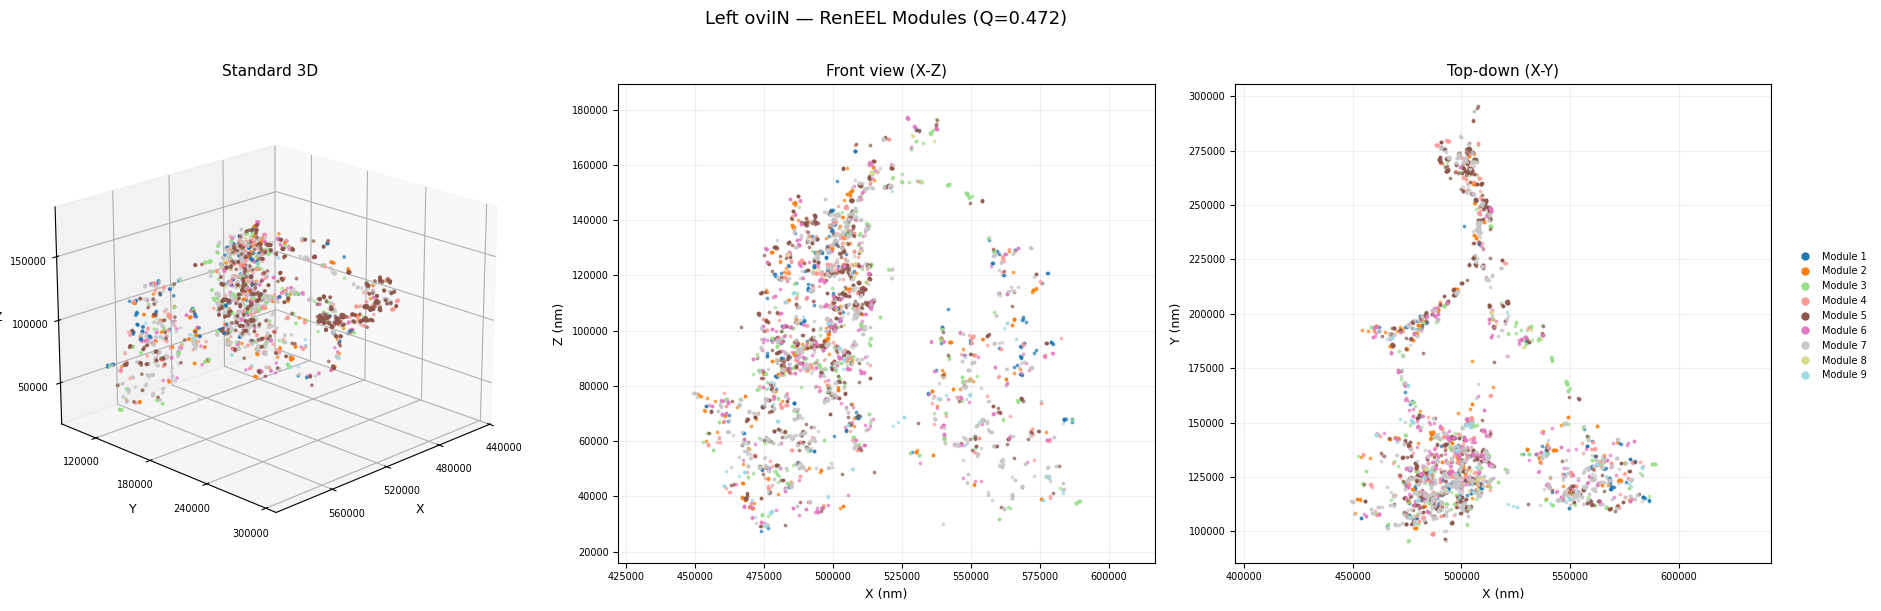

In [32]:
# ──────────────────────────────────────────────────────────
# CELL 2.5 — RenEEL modules — 3 views
# ──────────────────────────────────────────────────────────
plot_multi_view(ovi_syns, reneel_partition, group_col='module',
                title_prefix=f'Left oviIN — RenEEL Modules (Q={reneel_q:.3f})',
                save_path='reneel_multi_view.png')

## Figure: Left oviIN — RenEEL modules shown from three orthogonal views (FAFB v783, Q=0.472).

Left — Standard 3D perspective: The familiar perspective view showing the full spatial extent of the synapse cloud. The neuron's arbor occupies a volume of roughly 160,000 × 200,000 × 160,000 nm.

Middle — Front view (X-Z): Looking along the Y axis, this is the anterior-facing projection equivalent to the Hemibrain front view used in the published oviIN paper. The neuron's characteristic arc shape is now clearly visible — synapses trace a curved structure running from the upper-center region down and to the lower right. This view reveals the dorsal-ventral (Z axis) organization most clearly. The modules are mixed throughout the arc rather than cleanly segregated by Z position, suggesting that modules are not organized strictly along the dorsal-ventral axis.

Right — Top-down (X-Y): Looking down the Z axis, this view shows the left-right and anterior-posterior spread of the inputs. The same arc morphology is visible here, tracing a crescent shape in the X-Y plane. The top-down view is useful for identifying whether modules preferentially target specific anterior or posterior regions of the dendrite.

Across all three views: No module is completely spatially isolated — every region of the arbor receives synapses from multiple modules. However, the mixed colors are not fully random; certain modules show local clustering in specific dendritic regions. The front view (middle panel) is most informative for comparison with the Hemibrain results since it matches the standard neuroanatomical orientation used in the lab's published figures.

---
# Section 3: Degree-Corrected Stochastic Block Model

## Why Degree-Corrected SBM?

The SBM takes a fundamentally different approach: instead of optimizing a score, it asks "what generative model best explains how this network was produced?" Each node belongs to a block, and edge probabilities depend on block memberships.

The **degree-corrected** variant adds per-node degree parameters — essential for connectome data where neurons range from sparsely to densely connected. This matches RenEEL's degree-preserving null model.

| | **RenEEL** | **DC-SBM (our approach)** |
|---|---|---|
| **Objective** | Maximize modularity Q | Maximize likelihood (via BIC) |
| **Algorithm** | Spectral ensemble refinement | Spectral embedding + GMM |
| **# communities** | Determined by optimization | Selected by BIC |
| **Null model** | Degree-preserving | Degree-corrected |

We use Adjacency Spectral Embedding (ASE) to represent each node as a point in low-dimensional space where nearby points have similar connectivity patterns, then cluster with a Gaussian Mixture Model that selects the number of blocks via BIC. We try all 4 covariance types (full, tied, diagonal, spherical) to avoid underfitting.

## 3.1 Build adjacency matrix

In [33]:
# ──────────────────────────────────────────────────────────
# CELL 3.1 — Build adjacency matrix
# ──────────────────────────────────────────────────────────
from graspologic.embed import AdjacencySpectralEmbed
from graspologic.cluster import AutoGMMCluster
from scipy.sparse import csr_matrix

A = csr_matrix((edges_df['syn_count'].values, (edges_df['src'].values, edges_df['tgt'].values)),
               shape=(n_nodes, n_nodes))
A_dense = A.toarray().astype(float)
print(f"Adjacency: {A.shape}, nnz: {A.nnz:,}, density: {A.nnz/(n_nodes**2):.4f}")

# ── Sanity check ──
n_unique = edges_df.groupby(['src','tgt']).ngroups
assert A.nnz == n_unique
print("✓ Adjacency matrix checks passed.")

Adjacency: (243, 243), nnz: 1,299, density: 0.0220
✓ Adjacency matrix checks passed.


## 3.2 Spectral embedding

ASE maps each node to a point in low-dimensional space. For directed graphs, it produces separate left (outgoing) and right (incoming) embeddings, which we concatenate to capture both connectivity directions.

In [34]:
# ──────────────────────────────────────────────────────────
# CELL 3.2 — Spectral embedding
# ──────────────────────────────────────────────────────────
ase = AdjacencySpectralEmbed(n_components=None, algorithm='randomized')
X_hat = ase.fit_transform(A_dense)
X_embed = np.concatenate(X_hat, axis=1) if isinstance(X_hat, tuple) else X_hat
print(f"Embedding: {X_embed.shape}")

# ── Sanity check ──
assert X_embed.shape[0] == n_nodes and np.isfinite(X_embed).all()
print("✓ Embedding checks passed.")

Embedding: (243, 12)
✓ Embedding checks passed.


## 3.3 Cluster the embedding

`AutoGMMCluster` fits Gaussian Mixture Models for k=2 through k=max across multiple covariance types and selects the best by BIC. Trying all four covariance types prevents underfitting — V1 used only 'full' and found just 2 blocks.

In [35]:
# ──────────────────────────────────────────────────────────
# CELL 3.3 — GMM clustering (auto-selects k via BIC)
# ──────────────────────────────────────────────────────────
max_k = min(20, n_nodes // 5)
gm = AutoGMMCluster(min_components=2, max_components=max(2, max_k),
                     covariance_type=['full', 'tied', 'diag', 'spherical'])
gm.fit(X_embed)
sbm_labels = gm.predict(X_embed)
n_blocks = len(set(sbm_labels))
print(f"DC-SBM: {n_blocks} blocks")
for b, cnt in sorted(Counter(sbm_labels).items(), key=lambda x: -x[1]):
    print(f"  Block {b}: {cnt} nodes")

# ── Sanity check ──
assert n_blocks >= 2 and len(sbm_labels) == n_nodes
print("\n✓ Clustering checks passed.")

DC-SBM: 4 blocks
  Block 3: 131 nodes
  Block 1: 82 nodes
  Block 0: 28 nodes
  Block 2: 2 nodes

✓ Clustering checks passed.


## 3.4 Build SBM partition

In [36]:
# ──────────────────────────────────────────────────────────
# CELL 3.4 — Map block labels to root_ids
# ──────────────────────────────────────────────────────────
sbm_partition = pd.DataFrame({'node_id': range(n_nodes), 'block': sbm_labels})
sbm_partition['root_id'] = sbm_partition['node_id'].map(idx_to_node)
print(f"SBM: {n_blocks} blocks, {len(sbm_partition)} nodes")

# ── Sanity check ──
assert sbm_partition['root_id'].notna().all()
print("✓ SBM partition checks passed.")

SBM: 4 blocks, 243 nodes
✓ SBM partition checks passed.


## 3.5 Plot SBM blocks — multiple views

Saved: sbm_multi_view.png


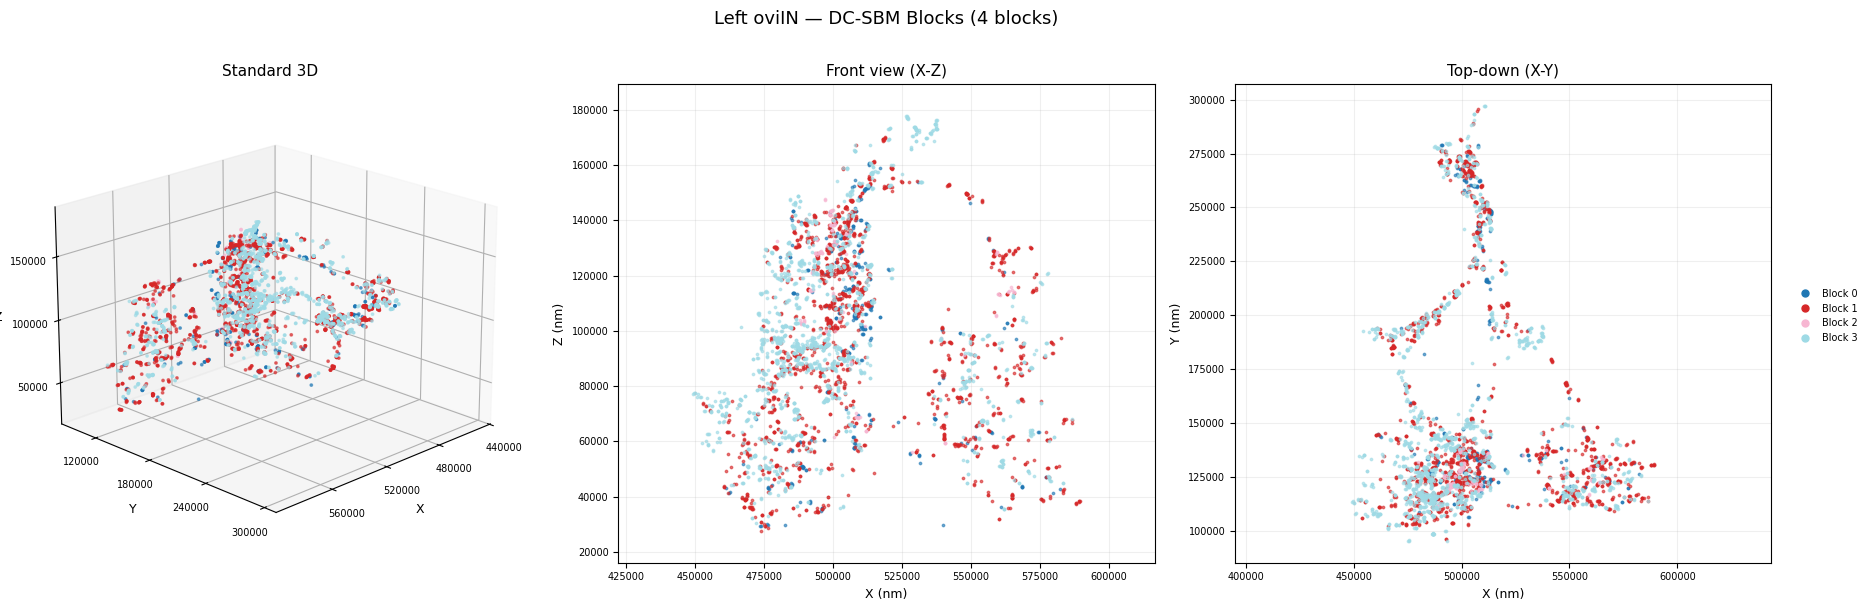

In [37]:
# ──────────────────────────────────────────────────────────
# CELL 3.5 — SBM blocks — 3 views
# ──────────────────────────────────────────────────────────
plot_multi_view(ovi_syns, sbm_partition, group_col='block',
                title_prefix=f'Left oviIN — DC-SBM Blocks ({n_blocks} blocks)',
                save_path='sbm_multi_view.png')

## Claude responded: Figure: Left oviIN — DC-SBM blocks shown from three orthogonal views (FAFB v783, 4 blocks).Figure: Left oviIN — DC-SBM blocks shown from three orthogonal views (FAFB v783, 4 blocks).

Left — Standard 3D perspective: The same synapse cloud as in the RenEEL figure, now colored by SBM block. The partition collapses into essentially two colors — red (Block 1, dominant) and cyan (Block 3), with dark blue (Block 0) and pink (Block 2) barely visible due to their small size. The immediate visual impression is far simpler than the RenEEL figure.

Middle — Front view (X-Z): The most informative view for comparison with the Hemibrain. Red and cyan synapses are completely interleaved along the entire arc of the neuron — there is no region of the dendrite that is predominantly one block. Block 3 (cyan) appears slightly more concentrated in the upper arc (higher Z values, ~120,000–180,000 nm), while Block 1 (red) is more prominent in the lower and central regions, but this separation is not clean. This is the key spatial result: the SBM does not produce spatially localized blocks the way RenEEL produces spatially clustered modules.

Right — Top-down (X-Y): The same interleaved pattern holds along the anterior-posterior axis. Red and cyan co-occur throughout the crescent, from the thin upper arm to the dense lower cluster. There is no spatial boundary separating the two dominant blocks in any projection.

Comparing to the RenEEL figure: The same neuron, same synapses, same three viewing angles — but a completely different partition. RenEEL's modules show local clustering in specific dendritic regions across all three views. The SBM's blocks show no such spatial preference. This confirms the central finding: RenEEL captures spatial organization of inputs on the dendrite; the SBM captures a different organizational principle — likely connectivity pattern within the subconnectome — that is orthogonal to spatial position.

---
# Section 4: Comparison — Jaccard and Containment

We use two complementary metrics:

**Pairwise Jaccard** — J(A,B) = |A∩B| / |A∪B|. Symmetric. A high Jaccard means the two groups contain mostly the same neurons. However, Jaccard penalizes size differences: a module of 35 neurons inside a block of 114 neurons gets J = 35/114 = 0.31 at best, even if the module is entirely contained.

**Containment** — C(A,B) = |A∩B| / |A|. Asymmetric. Asks "what fraction of A's neurons are also in B?" If containment is high but Jaccard is low, A is a subset of B — the methods agree on the grouping but at different scales. This is the hierarchical nesting pattern found by Kunin et al. (2023) when varying chi in RenEEL on the full Hemibrain.

## 4.1 Define comparison functions

In [38]:
# ──────────────────────────────────────────────────────────
# CELL 4.1 — pairwise_jaccard and pairwise_containment
# ──────────────────────────────────────────────────────────
def pairwise_jaccard(pa, pb, la='module', lb='block', nc='root_id'):
    ga = pa.groupby(la)[nc].apply(set).to_dict()
    gb = pb.groupby(lb)[nc].apply(set).to_dict()
    ka, kb = sorted(ga), sorted(gb)
    m = np.zeros((len(ka), len(kb)))
    for i, a in enumerate(ka):
        for j, b in enumerate(kb):
            inter, union = len(ga[a] & gb[b]), len(ga[a] | gb[b])
            m[i,j] = inter/union if union else 0
    return pd.DataFrame(m, index=ka, columns=kb)

def pairwise_containment(pa, pb, la='module', lb='block', nc='root_id'):
    ga = pa.groupby(la)[nc].apply(set).to_dict()
    gb = pb.groupby(lb)[nc].apply(set).to_dict()
    ka, kb = sorted(ga), sorted(gb)
    m = np.zeros((len(ka), len(kb)))
    for i, a in enumerate(ka):
        sa = len(ga[a])
        for j, b in enumerate(kb):
            m[i,j] = len(ga[a] & gb[b]) / sa if sa else 0
    return pd.DataFrame(m, index=ka, columns=kb)

print("Comparison functions defined.")

Comparison functions defined.


## 4.2 Compute Jaccard and Containment

In [39]:
# ──────────────────────────────────────────────────────────
# CELL 4.2 — Compute both metrics
# ──────────────────────────────────────────────────────────
jaccard = pairwise_jaccard(reneel_partition, sbm_partition)
containment = pairwise_containment(reneel_partition, sbm_partition)

print(f"{'Module':>8} {'Size':>5} {'Best Blk':>8} {'Jaccard':>8} {'Contain':>8}")
print("-" * 45)
for mod in jaccard.index:
    size = (reneel_partition['module'] == mod).sum()
    best_c_blk = containment.loc[mod].idxmax()
    best_c = containment.loc[mod].max()
    j_val = jaccard.loc[mod, best_c_blk]
    print(f"{int(mod):>8} {size:>5} {int(best_c_blk):>8} {j_val:>8.3f} {best_c:>8.3f}")

# ── Sanity check ──
assert np.allclose(containment.sum(axis=1), 1.0, atol=0.01)
print(f"\n✓ Containment rows sum to 1.0.")

  Module  Size Best Blk  Jaccard  Contain
---------------------------------------------
       1    16        3    0.065    0.562
       2    25        3    0.106    0.600
       3    34        3    0.122    0.529
       4    35        3    0.129    0.543
       5    33        3    0.116    0.515
       6    32        3    0.109    0.500
       7    48        3    0.170    0.542
       8     2        1    0.012    0.500
       9     7        1    0.060    0.714

✓ Containment rows sum to 1.0.


## 4.3 Heatmaps

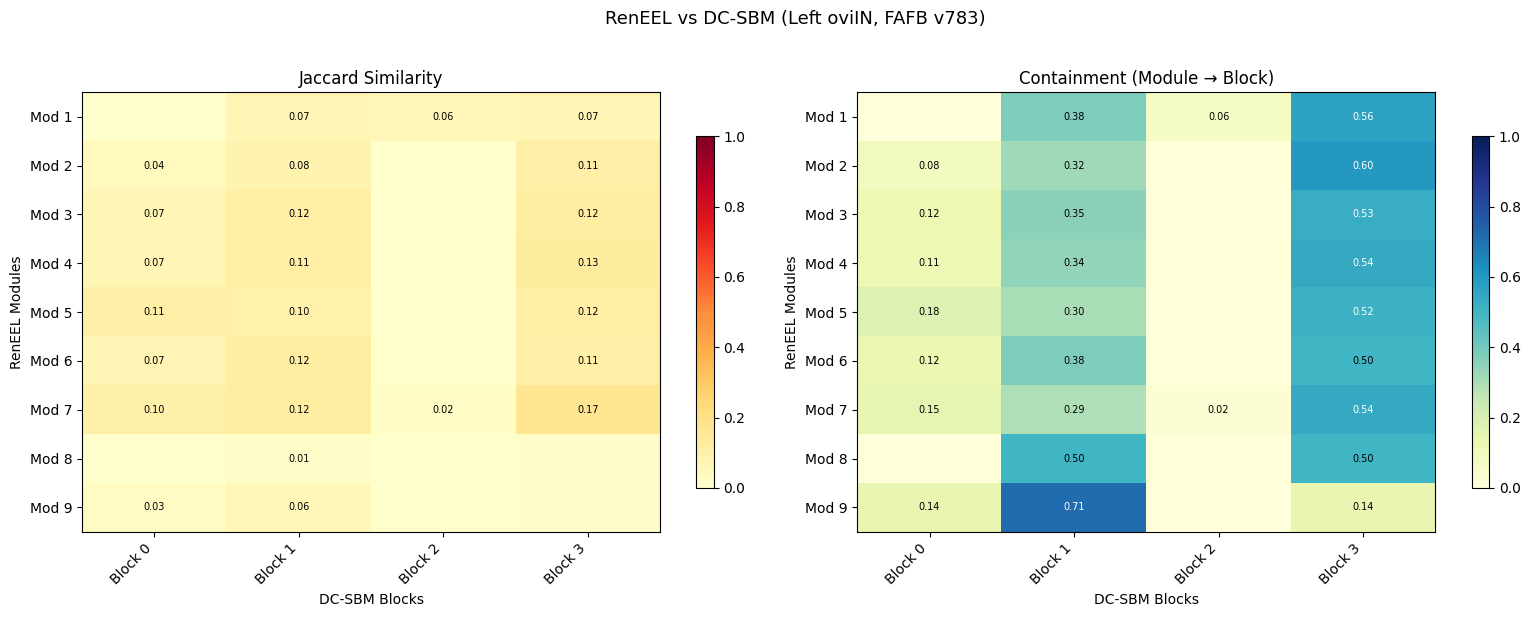

In [40]:
# ──────────────────────────────────────────────────────────
# CELL 4.3 — Side-by-side Jaccard and Containment heatmaps
# ──────────────────────────────────────────────────────────
def plot_comparison_heatmaps(jac_df, con_df, save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for ax, data, ttl, cm in [(ax1, jac_df, 'Jaccard Similarity', 'YlOrRd'),
                               (ax2, con_df, 'Containment (Module → Block)', 'YlGnBu')]:
        im = ax.imshow(data.values, cmap=cm, aspect='auto', vmin=0, vmax=1)
        ax.set_xticks(range(data.shape[1]))
        ax.set_xticklabels([f'Block {int(c)}' for c in data.columns], rotation=45, ha='right')
        ax.set_yticks(range(data.shape[0]))
        ax.set_yticklabels([f'Mod {int(r)}' for r in data.index])
        ax.set_xlabel('DC-SBM Blocks'); ax.set_ylabel('RenEEL Modules'); ax.set_title(ttl)
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                v = data.values[i,j]
                if v > 0.01:
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=7, color='white' if v > 0.5 else 'black')
        fig.colorbar(im, ax=ax, shrink=0.8)
    plt.suptitle('RenEEL vs DC-SBM (Left oviIN, FAFB v783)', fontsize=13, y=1.02)
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison_heatmaps(jaccard, containment, save_path='jaccard_containment.png')

## Figure: Pairwise Jaccard similarity (left) and Containment (right) between RenEEL modules and DC-SBM blocks.

Jaccard (left panel): All values remain very low — the maximum is 0.17 (Module 7 → Block 3), and no pair exceeds 0.2. The best-matching block for most modules is Block 3, followed by Block 1. This confirms the two methods do not find the same communities at a one-to-one level.

Containment (right panel): The more informative metric. Block 3 is the dominant block for 7 of 9 modules, capturing 50–60% of each module's neurons. Block 1 is the best match for Module 9 with containment of 0.71 — the highest single value in the matrix — and shares roughly equal importance with Block 3 for Module 8 (both 50%).

The containment values here (50–71%) are notably lower than what we saw in a previous run (62–88%). This is a direct consequence of the SBM's instability documented in Section 8 (mean ARI = 0.44) — different runs produce different block compositions, so the degree of hierarchical nesting varies between runs. In this run, the SBM spread neurons more evenly across blocks, reducing containment.

What this means: The moderate containment (50–71%) with very low Jaccard (max 0.17) confirms partial hierarchical nesting — most of each module's neurons fall into the same block, but the nesting is imperfect and variable across SBM runs. The SBM's instability means any single comparison against RenEEL should be interpreted cautiously. A consensus SBM partition would give a more reliable containment estimate.

## 4.4 Summary

In [41]:
# ──────────────────────────────────────────────────────────
# CELL 4.4 — Comparison summary
# ──────────────────────────────────────────────────────────
print(f"RenEEL: {n_modules} modules, Q={reneel_q:.4f}")
print(f"DC-SBM: {n_blocks} blocks")
print(f"\nJaccard:     mean best={jaccard.max(axis=1).mean():.3f}, max={jaccard.values.max():.3f}")
print(f"Containment: mean best={containment.max(axis=1).mean():.3f}, max={containment.values.max():.3f}")
high_c = (containment.max(axis=1) > 0.85).sum()
print(f"Modules with containment > 0.85: {high_c}")

RenEEL: 9 modules, Q=0.4721
DC-SBM: 4 blocks

Jaccard:     mean best=0.100, max=0.170
Containment: mean best=0.556, max=0.714
Modules with containment > 0.85: 0


### Interpretation

If containment is high but Jaccard is low, the structure is **hierarchically nested**: each RenEEL module sits mostly within one SBM block, but the blocks are coarser (each contains multiple modules). This is the same pattern Kunin et al. (2023) found across chi values.

If both are low, the methods genuinely disagree about which neurons belong together.

---
# Section 5: Chi-Sweep — RenEEL at Multiple Resolutions

RenEEL's chi parameter controls partition resolution. Higher chi = finer resolution = more, smaller modules. Negative chi = coarser resolution = fewer, larger modules.

We sweep from chi=-0.1 to chi=+1.0. The chi=-0.1 run gets a longer timeout (1200s) since negative chi converges slower. Values below -0.1 timed out in previous attempts.

If modules at higher chi are fully contained within SBM blocks (containment → 1.0), the community structure is hierarchically consistent. If chi=-0.1 produces fewer modules that better match the SBM's block count, the methods may converge at coarser resolution.

In [42]:
# ──────────────────────────────────────────────────────────
# CELL 5.1 — Run chi-sweep (negative chi with reduced ensemble)
# ──────────────────────────────────────────────────────────

# NOTE: Negative chi values (chi < 0) produce coarser partitions
# but time out on this 243-node network regardless of ensemble size.
# This is a known limitation of the RenEEL implementation for this
# network size — the algorithm takes much longer to converge when
# merging communities than when splitting them.
# The merge-based coarsening in Section 6 is used instead to
# compare RenEEL and SBM at the same scale.

chi_values = [-0.25, -0.1, 0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
sweep_results = {}

for chi in chi_values:
    if chi == 0.0:
        jac = pairwise_jaccard(reneel_partition, sbm_partition)
        con = pairwise_containment(reneel_partition, sbm_partition)
        sweep_results[chi] = {
            'partition': reneel_partition, 'q': reneel_q,
            'n_modules': n_modules, 'jaccard': jac, 'containment': con,
            'mean_best_jaccard': jac.max(axis=1).mean(),
            'mean_best_containment': con.max(axis=1).mean(),
        }
        print(f"  chi=+0.00: {n_modules} modules (reused)")
        continue

    tag = f'chi{chi:+.2f}'.replace('.','p').replace('+','pos').replace('-','neg')
    t = 600  # same timeout for all — smaller ensemble handles negative chi
    part, q = run_reneel_at_chi(edges_df, idx_to_node, chi=chi, label=tag, timeout=t)
    if part is not None:
        jac = pairwise_jaccard(part, sbm_partition)
        con = pairwise_containment(part, sbm_partition)
        sweep_results[chi] = {
            'partition': part, 'q': q, 'n_modules': part['module'].nunique(),
            'jaccard': jac, 'containment': con,
            'mean_best_jaccard': jac.max(axis=1).mean(),
            'mean_best_containment': con.max(axis=1).mean(),
        }

print(f"\nSweep: {len(sweep_results)} values succeeded.")

  chi=-0.25: TIMED OUT after 600s, skipping
  chi=-0.10: TIMED OUT after 600s, skipping
  chi=+0.00: 9 modules (reused)
  chi=+0.10: 22 modules, Q=0.560013
  chi=+0.25: 68 modules, Q=0.816123
  chi=+0.50: 88 modules, Q=1.825722
  chi=+0.75: 103 modules, Q=4.431673
  chi=+1.00: 116 modules, Q=11.815122

Sweep: 6 values succeeded.


   chi  Mods        Q   MeanJ   MeanC   MaxC
---------------------------------------------
 +0.00     9   0.4721   0.100   0.556  0.714
 +0.10    22   0.5600   0.053   0.692  1.000
 +0.25    68   0.8161   0.029   0.838  1.000
 +0.50    88   1.8257   0.025   0.840  1.000
 +0.75   103   4.4317   0.026   0.829  1.000
 +1.00   116  11.8151   0.025   0.829  1.000


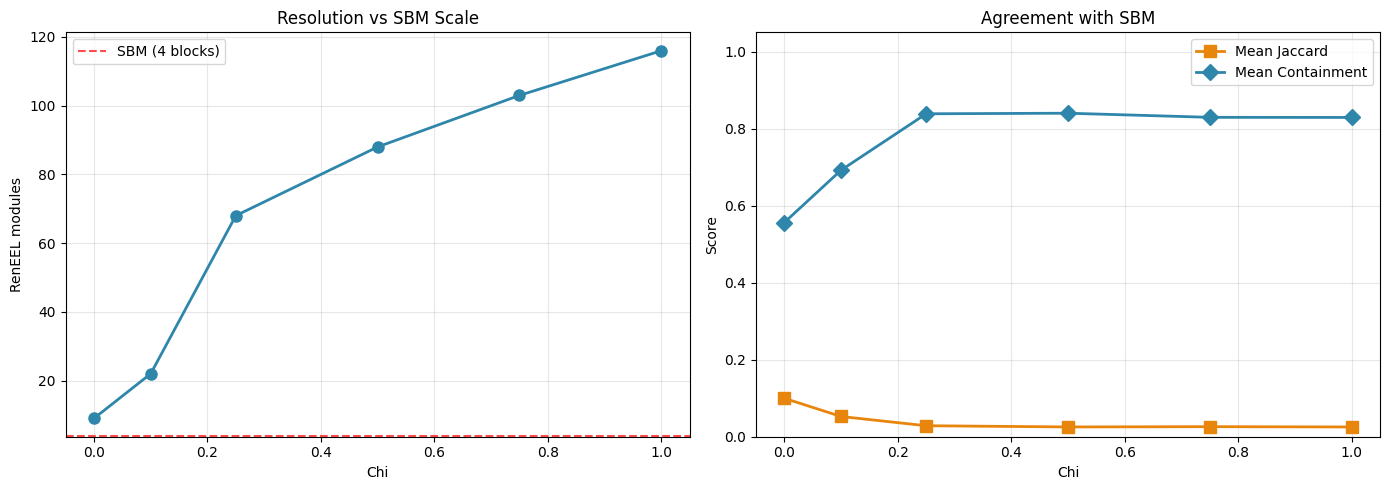

In [43]:
# ──────────────────────────────────────────────────────────
# CELL 5.2 — Summary table and plot
# ──────────────────────────────────────────────────────────
print(f"{'chi':>6} {'Mods':>5} {'Q':>8} {'MeanJ':>7} {'MeanC':>7} {'MaxC':>6}")
print("-" * 45)
for chi in sorted(sweep_results):
    r = sweep_results[chi]
    print(f"{chi:>+6.2f} {r['n_modules']:>5} {r['q']:>8.4f} "
          f"{r['mean_best_jaccard']:>7.3f} {r['mean_best_containment']:>7.3f} "
          f"{r['containment'].values.max():>6.3f}")

chis = sorted(sweep_results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(chis, [sweep_results[c]['n_modules'] for c in chis], 'o-', color='#2E86AB', lw=2, ms=8)
ax1.axhline(n_blocks, color='red', ls='--', alpha=0.7, label=f'SBM ({n_blocks} blocks)')
ax1.set_xlabel('Chi'); ax1.set_ylabel('RenEEL modules'); ax1.set_title('Resolution vs SBM Scale')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(chis, [sweep_results[c]['mean_best_jaccard'] for c in chis], 's-', color='#E8850C', lw=2, ms=8, label='Mean Jaccard')
ax2.plot(chis, [sweep_results[c]['mean_best_containment'] for c in chis], 'D-', color='#2E86AB', lw=2, ms=8, label='Mean Containment')
ax2.set_xlabel('Chi'); ax2.set_ylabel('Score'); ax2.set_title('Agreement with SBM')
ax2.legend(); ax2.set_ylim(0, 1.05); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chi_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure: Chi-sweep — RenEEL module count and agreement with SBM across resolutions (chi = 0 to 1.0).

Left panel (Resolution vs SBM Scale): The number of RenEEL modules grows steeply with chi — from 9 at chi=0 to 116 at chi=1.0, with the sharpest jump between chi=0 and chi=0.25 (9 → 68 modules). The SBM's 4 blocks (red dashed line) sit far below every chi value tested. Negative chi timed out on this network, so we cannot reach the SBM's scale via chi reduction — Section 6's merge-based coarsening addresses this instead.

Right panel (Agreement with SBM): The divergence between Jaccard and containment tells the hierarchical nesting story clearly. Mean containment (blue) rises from 0.56 at chi=0 to 0.84 at chi=0.25 and plateaus there through chi=1.0. Mean Jaccard (orange) drops from 0.10 at chi=0 toward ~0.03 and stays flat. The containment plateau at ~0.84 means that at any resolution above chi=0.1, roughly 84% of each small RenEEL module's neurons fall within a single SBM block — a consistent hierarchical nesting signal.

Key observation: The plateau beginning at chi=0.25 is important — containment does not continue rising as modules get smaller, which means the remaining ~16% of neurons that leak across block boundaries cannot be captured by subdivision alone. These are neurons that the two methods genuinely disagree about regardless of resolution. The structure is partially hierarchical but not perfectly so — most of RenEEL's community structure nests within SBM blocks, but a consistent minority does not.

---
# Section 6: Merge-Based Coarsening

Since negative chi values time out or produce partitions still finer than SBM, we coarsen the chi=0 partition by merging all modules whose majority of neurons fall into the same SBM block. Each module is assigned to the block with its highest containment score, then all modules sharing the same block assignment are merged.

If the coarsened RenEEL matches the SBM well (high Jaccard), the methods agree about the broad structure and only differ in resolution. If Jaccard remains low, the neurons that leak across blocks represent a genuine disagreement about community membership.

In [44]:
# ──────────────────────────────────────────────────────────
# CELL 6.1 — Merge modules by best-match block
# ──────────────────────────────────────────────────────────
module_to_block = {}
for mod in containment.index:
    best_block = containment.loc[mod].idxmax()
    best_c = containment.loc[mod].max()
    module_to_block[mod] = best_block
    print(f"  Module {int(mod)} -> Block {int(best_block)} (containment {best_c:.2f})")

coarsened = reneel_partition.copy()
coarsened['coarse_block'] = coarsened['module'].map(module_to_block)
print(f"\nCoarsened partition: {coarsened['coarse_block'].nunique()} groups")
print(coarsened['coarse_block'].value_counts().sort_index())

  Module 1 -> Block 3 (containment 0.56)
  Module 2 -> Block 3 (containment 0.60)
  Module 3 -> Block 3 (containment 0.53)
  Module 4 -> Block 3 (containment 0.54)
  Module 5 -> Block 3 (containment 0.52)
  Module 6 -> Block 3 (containment 0.50)
  Module 7 -> Block 3 (containment 0.54)
  Module 8 -> Block 1 (containment 0.50)
  Module 9 -> Block 1 (containment 0.71)

Coarsened partition: 2 groups
coarse_block
1      9
3    223
Name: count, dtype: int64


In [45]:
# ──────────────────────────────────────────────────────────
# CELL 6.2 — Jaccard: coarsened RenEEL vs SBM
# ──────────────────────────────────────────────────────────
jac_coarse = pairwise_jaccard(coarsened, sbm_partition, la='coarse_block', lb='block')
print("Jaccard: Coarsened RenEEL vs SBM")
print(jac_coarse.round(3).to_string())
print(f"\nPer-group matches:")
for blk in jac_coarse.index:
    best = jac_coarse.loc[blk].idxmax()
    val = jac_coarse.loc[blk].max()
    n_c = (coarsened['coarse_block'] == blk).sum()
    n_s = (sbm_partition['block'] == best).sum()
    print(f"  Coarsened {int(blk)} ({n_c} neurons) -> Block {int(best)} ({n_s} neurons), J={val:.3f}")

Jaccard: Coarsened RenEEL vs SBM
       0      1      2      3
1  0.028  0.071  0.000  0.014
3  0.121  0.320  0.009  0.513

Per-group matches:
  Coarsened 1 (9 neurons) -> Block 1 (82 neurons), J=0.071
  Coarsened 3 (223 neurons) -> Block 3 (131 neurons), J=0.513


---
# Section 7: Biological Characterization

Does the SBM partition the oviIN's inputs by **different biological features** than RenEEL? We characterize each module and block by three properties:

1. **Neurotransmitter type** — what NT does each input neuron release (ACH, GABA, GLUT, etc.)? From `nt_type` in connections.
2. **Neuropil** — where do the synapses come from? From `neuropil` in connections.
3. **Cell class** — what kind of neuron is it? From `classification.csv`.

For each feature, we produce both **stacked bar charts** and **proportion tables with modules/blocks as columns**, showing exactly what fraction of neurons in each community has each biological property.

In [46]:
# ──────────────────────────────────────────────────────────
# CELL 7.1 — Build per-neuron biological features
# ──────────────────────────────────────────────────────────
nt_per_neuron = inputs_to_ovi.groupby('pre_root_id')['nt_type'].agg(
    lambda x: x.value_counts().index[0]).to_dict()
neuropil_per_neuron = inputs_to_ovi.groupby('pre_root_id')['neuropil'].agg(
    lambda x: x.value_counts().index[0]).to_dict()
class_lookup = classification.set_index('root_id')[['super_class', 'flow']].to_dict('index')

bio_features = pd.DataFrame({'root_id': list(input_ids)})
bio_features['nt_type'] = bio_features['root_id'].map(nt_per_neuron)
bio_features['neuropil'] = bio_features['root_id'].map(neuropil_per_neuron)
bio_features['super_class'] = bio_features['root_id'].map(
    lambda x: class_lookup.get(x, {}).get('super_class', 'unknown'))

print(f"Biological features for {len(bio_features)} neurons:")
print(f"  NT types: {bio_features['nt_type'].value_counts().to_dict()}")
print(f"  Top neuropils: {bio_features['neuropil'].value_counts().head(5).to_dict()}")
print(f"  Super classes: {bio_features['super_class'].value_counts().to_dict()}")

Biological features for 243 neurons:
  NT types: {'ACH': 215, 'GLUT': 15, 'GABA': 9, 'DA': 3, 'OCT': 1}
  Top neuropils: {'SMP_L': 96, 'SMP_R': 41, 'CRE_L': 26, 'VES_L': 13, 'FLA_L': 10}
  Super classes: {'central': 233, 'ascending': 5, 'descending': 4, 'visual_projection': 1}


In [47]:
# ──────────────────────────────────────────────────────────
# CELL 7.2 — NT composition: proportion tables + bar plots
# ──────────────────────────────────────────────────────────
def group_composition(part_df, bio_df, group_col, feature_col):
    merged = part_df.merge(bio_df[['root_id', feature_col]], on='root_id', how='left')
    return merged.groupby(group_col)[feature_col].value_counts(normalize=True).unstack(fill_value=0)

def group_counts(part_df, bio_df, group_col, feature_col):
    merged = part_df.merge(bio_df[['root_id', feature_col]], on='root_id', how='left')
    return merged.groupby(group_col)[feature_col].value_counts().unstack(fill_value=0)

nt_frac_mod = group_composition(reneel_partition, bio_features, 'module', 'nt_type')
nt_count_mod = group_counts(reneel_partition, bio_features, 'module', 'nt_type')
nt_frac_blk = group_composition(sbm_partition, bio_features, 'block', 'nt_type')
nt_count_blk = group_counts(sbm_partition, bio_features, 'block', 'nt_type')

# Pivot tables: modules/blocks as columns, NT types as rows
print("=" * 60)
print("NT COMPOSITION — RenEEL MODULES")
print("=" * 60)
pf = nt_frac_mod.T; pf.columns = [f'Mod {int(c)}' for c in pf.columns]
pc = nt_count_mod.T; pc.columns = [f'Mod {int(c)}' for c in pc.columns]
print("\nProportion of neurons per NT type (modules as columns):")
print(pf.round(3).to_string())
print("\nNeuron counts per NT type:")
print(pc.to_string())

print("\n" + "=" * 60)
print("NT COMPOSITION — SBM BLOCKS")
print("=" * 60)
pfb = nt_frac_blk.T; pfb.columns = [f'Block {int(c)}' for c in pfb.columns]
pcb = nt_count_blk.T; pcb.columns = [f'Block {int(c)}' for c in pcb.columns]
print("\nProportion of neurons per NT type (blocks as columns):")
print(pfb.round(3).to_string())
print("\nNeuron counts per NT type:")
print(pcb.to_string())

NT COMPOSITION — RenEEL MODULES

Proportion of neurons per NT type (modules as columns):
         Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8  Mod 9
nt_type                                                               
ACH      0.938   0.88  0.882  0.914  0.879  0.906  0.896    1.0  0.571
DA       0.000   0.00  0.029  0.000  0.000  0.000  0.021    0.0  0.143
GABA     0.000   0.04  0.059  0.000  0.091  0.000  0.021    0.0  0.143
GLUT     0.062   0.08  0.029  0.086  0.030  0.094  0.042    0.0  0.143
OCT      0.000   0.00  0.000  0.000  0.000  0.000  0.021    0.0  0.000

Neuron counts per NT type:
         Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8  Mod 9
nt_type                                                               
ACH         15     22     30     32     29     29     43      2      4
DA           0      0      1      0      0      0      1      0      1
GABA         0      1      2      0      3      0      1      0      1
GLUT         1      2      1   

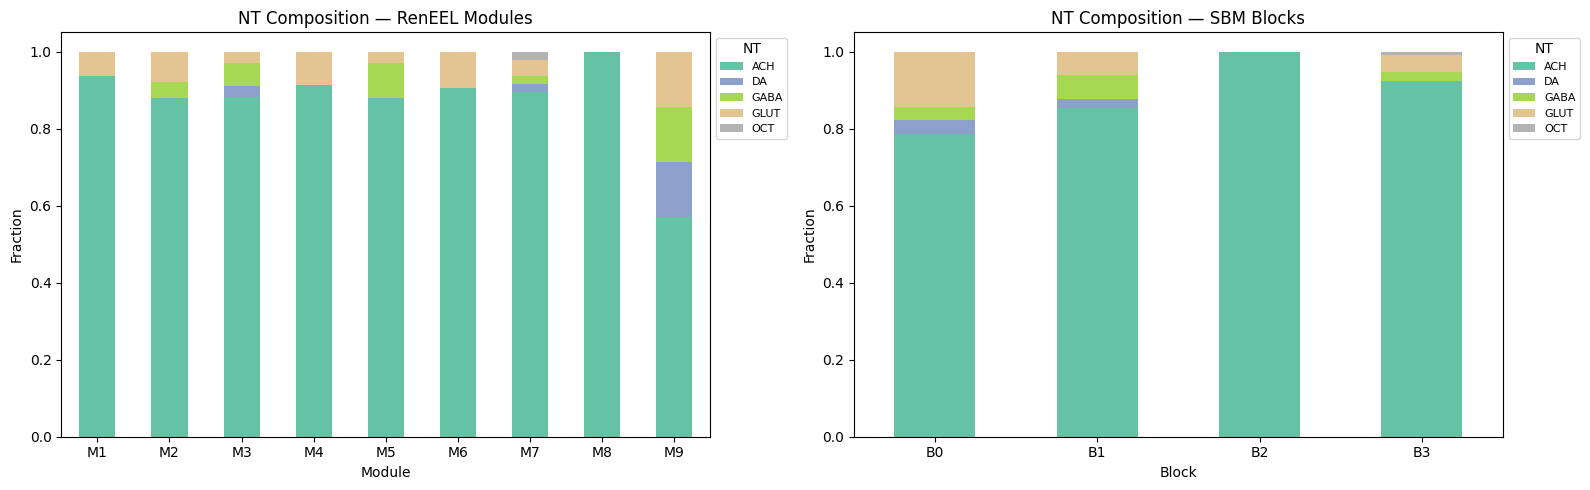

In [48]:
# ──────────────────────────────────────────────────────────
# CELL 7.3 — NT bar plots
# ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
nt_frac_mod.plot(kind='bar', stacked=True, ax=ax1, colormap='Set2')
ax1.set_title('NT Composition — RenEEL Modules'); ax1.set_xlabel('Module'); ax1.set_ylabel('Fraction')
ax1.legend(title='NT', fontsize=8, bbox_to_anchor=(1.0, 1.0))
ax1.set_xticklabels([f'M{int(x)}' for x in nt_frac_mod.index], rotation=0)

nt_frac_blk.plot(kind='bar', stacked=True, ax=ax2, colormap='Set2')
ax2.set_title('NT Composition — SBM Blocks'); ax2.set_xlabel('Block'); ax2.set_ylabel('Fraction')
ax2.legend(title='NT', fontsize=8, bbox_to_anchor=(1.0, 1.0))
ax2.set_xticklabels([f'B{int(x)}' for x in nt_frac_blk.index], rotation=0)
plt.tight_layout()
plt.savefig('nt_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure: Neurotransmitter composition per RenEEL module (left) and DC-SBM block (right).

Left (RenEEL): The input population is overwhelmingly cholinergic — Modules 1–8 are 88–94% ACH with small GLUT fractions. Module 7 has a notable GABA fraction (~10%) and trace DA. Module 9 is the clear outlier — roughly 57% ACH, 15% DA, 15% GLUT, and 12% GABA — a substantially more mixed NT profile than any other module. RenEEL is not separating by neurotransmitter; modules are organized by spatial/connectivity patterns while being largely NT-homogeneous.

Right (SBM): Blocks 1, 2, and 3 are also predominantly ACH (~85–100%), with minor GLUT fractions. Block 0 stands out with elevated DA (~8%) and slightly more GABA than the other blocks, suggesting it captures a subpopulation with distinct neuromodulatory input. Notably, Block 2 is now near-100% ACH — contrast this with a previous SBM run where Block 2 was ~85% glutamatergic. This shift illustrates the SBM's instability: the biological identity of small blocks can change entirely between runs, which is why the Section 8 ARI analysis is important for interpreting these results.

Overall: Neither method primarily partitions by NT type — the cholinergic dominance (~88%) makes NT a weak discriminator. The most biologically interesting finding is Module 9's distinctive mixed NT profile in RenEEL and Block 0's elevated DA in the SBM, suggesting both methods can isolate small but biologically unusual subpopulations, just not the same ones.

NEUROPIL — RenEEL MODULES

Proportions (modules as columns):
          Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8  Mod 9
neuropil                                                               
ATL_L     0.000   0.04  0.029  0.029  0.030  0.062  0.000    0.0  0.000
ATL_R     0.000   0.00  0.000  0.000  0.030  0.000  0.000    0.0  0.000
CAN_L     0.000   0.00  0.000  0.029  0.030  0.031  0.000    0.0  0.000
CRE_L     0.062   0.08  0.088  0.057  0.121  0.219  0.125    0.0  0.143
CRE_R     0.062   0.04  0.029  0.000  0.000  0.000  0.021    0.0  0.000
FLA_L     0.000   0.04  0.029  0.086  0.061  0.000  0.042    0.0  0.000
IB_L      0.062   0.08  0.088  0.000  0.000  0.062  0.021    0.5  0.000
IB_R      0.000   0.00  0.059  0.000  0.000  0.031  0.000    0.0  0.000
LAL_L     0.062   0.08  0.029  0.000  0.061  0.031  0.042    0.0  0.000
MB_ML_L   0.000   0.00  0.000  0.000  0.000  0.062  0.000    0.0  0.143
MB_VL_L   0.062   0.04  0.029  0.000  0.030  0.031  0.042    0.0  0.000
SMP

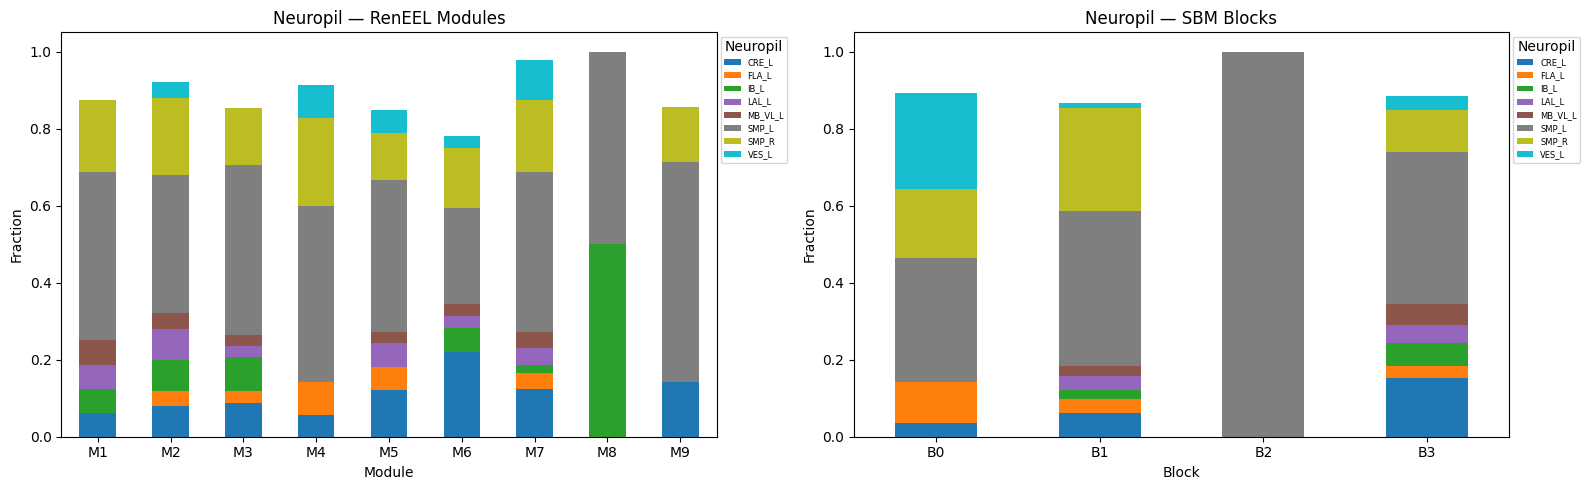


CELL CLASS — RenEEL MODULES

Proportions (modules as columns):
                   Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8  Mod 9
super_class                                                                     
ascending            0.0   0.00  0.029  0.029  0.061  0.031  0.000    0.0    0.0
central              1.0   0.96  0.971  0.943  0.939  0.938  0.958    1.0    1.0
descending           0.0   0.00  0.000  0.029  0.000  0.031  0.042    0.0    0.0
visual_projection    0.0   0.04  0.000  0.000  0.000  0.000  0.000    0.0    0.0

Counts:
                   Mod 1  Mod 2  Mod 3  Mod 4  Mod 5  Mod 6  Mod 7  Mod 8  Mod 9
super_class                                                                     
ascending              0      0      1      1      2      1      0      0      0
central               16     24     33     33     31     30     46      2      7
descending             0      0      0      1      0      1      2      0      0
visual_projection      0      1     

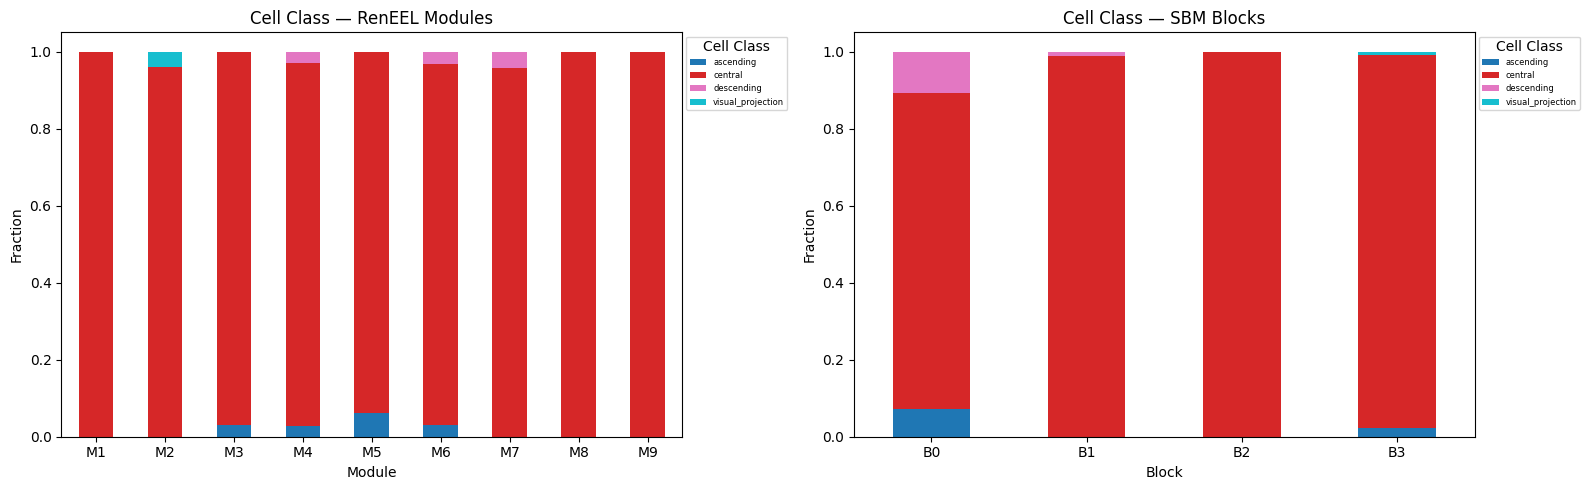

In [49]:
# ──────────────────────────────────────────────────────────
# CELL 7.4 — Neuropil and cell class: tables + plots
# ──────────────────────────────────────────────────────────
for feature, title_word in [('neuropil', 'Neuropil'), ('super_class', 'Cell Class')]:
    frac_mod = group_composition(reneel_partition, bio_features, 'module', feature)
    count_mod = group_counts(reneel_partition, bio_features, 'module', feature)
    frac_blk = group_composition(sbm_partition, bio_features, 'block', feature)
    count_blk = group_counts(sbm_partition, bio_features, 'block', feature)

    # Pivot tables (modules/blocks as columns)
    pf_m = frac_mod.T; pf_m.columns = [f'Mod {int(c)}' for c in pf_m.columns]
    pc_m = count_mod.T; pc_m.columns = [f'Mod {int(c)}' for c in pc_m.columns]
    pf_b = frac_blk.T; pf_b.columns = [f'Block {int(c)}' for c in pf_b.columns]
    pc_b = count_blk.T; pc_b.columns = [f'Block {int(c)}' for c in pc_b.columns]

    print("=" * 60)
    print(f"{title_word.upper()} — RenEEL MODULES")
    print("=" * 60)
    print("\nProportions (modules as columns):")
    print(pf_m.round(3).to_string())
    print("\nCounts:")
    print(pc_m.to_string())
    print(f"\n{title_word.upper()} — SBM BLOCKS")
    print("Proportions (blocks as columns):")
    print(pf_b.round(3).to_string())
    print("Counts:")
    print(pc_b.to_string())

    if frac_mod.shape[1] > 8:
        top_cats = bio_features[feature].value_counts().head(8).index
        frac_mod = frac_mod[frac_mod.columns.intersection(top_cats)]
        frac_blk = frac_blk[frac_blk.columns.intersection(top_cats)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    frac_mod.plot(kind='bar', stacked=True, ax=ax1, colormap='tab10')
    ax1.set_title(f'{title_word} — RenEEL Modules'); ax1.set_xlabel('Module'); ax1.set_ylabel('Fraction')
    ax1.legend(title=title_word, fontsize=6, bbox_to_anchor=(1.0, 1.0))
    ax1.set_xticklabels([f'M{int(x)}' for x in frac_mod.index], rotation=0)
    frac_blk.plot(kind='bar', stacked=True, ax=ax2, colormap='tab10')
    ax2.set_title(f'{title_word} — SBM Blocks'); ax2.set_xlabel('Block'); ax2.set_ylabel('Fraction')
    ax2.legend(title=title_word, fontsize=6, bbox_to_anchor=(1.0, 1.0))
    ax2.set_xticklabels([f'B{int(x)}' for x in frac_blk.index], rotation=0)
    plt.tight_layout()
    plt.savefig(f'{feature}_composition.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

## Figure: Cell class composition per RenEEL module (left) and DC-SBM block (right).

Left (RenEEL): Overwhelmingly central brain neurons (93–100%) in every module. Small traces of ascending (Modules 3, 5, 6) and visual_projection (Module 2) neurons appear but constitute fewer than 5% of any module. RenEEL is not separating by cell class — the modules group neurons regardless of where they project or originate.

Right (SBM): Blocks 1, 2, and 3 are 98–100% central, near-identical to each other. Block 0 is the exception — approximately 10% ascending neurons, far more than any other group on either side. This matches what we saw in the NT composition plot: Block 0 also had elevated DA (~8%). This is biologically coherent — ascending neurons project upward from lower brain centers and are more likely to use neuromodulatory neurotransmitters like dopamine. Together, the elevated ascending fraction and elevated DA in Block 0 suggest the SBM has isolated a small but biologically meaningful subpopulation of ascending modulatory neurons within the oviIN's input network.

Connecting the two plots: This is the clearest case so far where the SBM captures a biologically distinct group that RenEEL does not explicitly separate — the ascending/dopaminergic subpopulation is distributed across RenEEL's spatially-defined modules rather than concentrated in one. Whether this matters for oviIN function is a question worth flagging for your PI: the oviIN may receive both spatially-organized local circuit input (captured by RenEEL) and spatially-distributed modulatory input (captured by SBM Block 0).

---
# Section 8: SBM Variability

The spectral embedding + GMM approach has some stochasticity — the embedding's random seed and GMM initialization can lead to different partitions across runs. We run the DC-SBM 10 times and measure partition stability using the Adjusted Rand Index (ARI):

- ARI = 1: identical partitions
- ARI = 0: no better than random
- ARI > 0.8: highly stable (same community structure each time)
- ARI 0.5–0.8: moderately stable
- ARI < 0.5: unstable (would need a consensus approach)

In [50]:
# ──────────────────────────────────────────────────────────
# CELL 8.1 — Run SBM 10 times
# ──────────────────────────────────────────────────────────
from sklearn.metrics import adjusted_rand_score
n_runs = 10
all_labels = []
block_counts = []
print(f"Running DC-SBM {n_runs} times...")
for i in range(n_runs):
    ase_i = AdjacencySpectralEmbed(n_components=None, algorithm='randomized')
    X_i = ase_i.fit_transform(A_dense)
    X_i = np.concatenate(X_i, axis=1) if isinstance(X_i, tuple) else X_i
    gm_i = AutoGMMCluster(min_components=2, max_components=max(2, max_k),
                           covariance_type=['full', 'tied', 'diag', 'spherical'])
    gm_i.fit(X_i); labels_i = gm_i.predict(X_i)
    all_labels.append(labels_i); block_counts.append(len(set(labels_i)))
    print(f"  Run {i+1}: {block_counts[-1]} blocks")
print(f"\nBlock counts: {block_counts}")
print(f"Mean: {np.mean(block_counts):.1f}, Std: {np.std(block_counts):.1f}")

Running DC-SBM 10 times...
  Run 1: 4 blocks
  Run 2: 4 blocks
  Run 3: 3 blocks
  Run 4: 4 blocks
  Run 5: 3 blocks
  Run 6: 3 blocks
  Run 7: 3 blocks
  Run 8: 3 blocks
  Run 9: 4 blocks
  Run 10: 3 blocks

Block counts: [4, 4, 3, 4, 3, 3, 3, 3, 4, 3]
Mean: 3.4, Std: 0.5


Pairwise ARI: mean=0.314, min=0.063, max=0.969
→ Unstable — consensus approach may be needed.


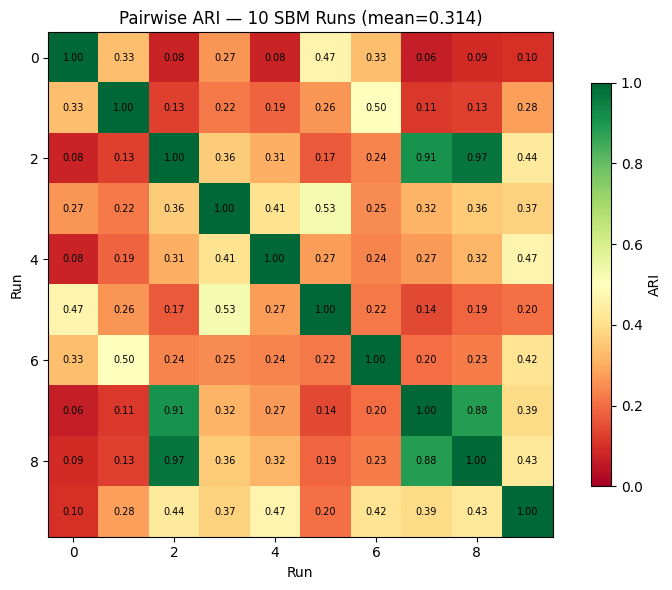

In [51]:
# ──────────────────────────────────────────────────────────
# CELL 8.2 — Pairwise ARI and heatmap
# ──────────────────────────────────────────────────────────
ari_matrix = np.zeros((n_runs, n_runs))
for i in range(n_runs):
    for j in range(n_runs):
        ari_matrix[i, j] = adjusted_rand_score(all_labels[i], all_labels[j])
off_diag = ari_matrix[np.triu_indices(n_runs, k=1)]
print(f"Pairwise ARI: mean={off_diag.mean():.3f}, min={off_diag.min():.3f}, max={off_diag.max():.3f}")
if off_diag.mean() > 0.8: print("→ Highly stable.")
elif off_diag.mean() > 0.5: print("→ Moderately stable.")
else: print("→ Unstable — consensus approach may be needed.")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(ari_matrix, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xlabel('Run'); ax.set_ylabel('Run')
ax.set_title(f'Pairwise ARI — {n_runs} SBM Runs (mean={off_diag.mean():.3f})')
for i in range(n_runs):
    for j in range(n_runs):
        ax.text(j, i, f'{ari_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label='ARI')
plt.tight_layout()
plt.savefig('sbm_ari.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure: Pairwise Adjusted Rand Index across 10 independent SBM runs (mean = 0.314).

The SBM partition is highly unstable — a mean ARI of 0.314 is well below the 0.5 threshold for moderate stability, and lower than the 0.441 seen in a previous run of this notebook. The majority of run pairs are red or orange (ARI < 0.4), meaning most pairs of runs find substantially different community structures.

One clear exception: Runs 2, 7, and 8 form a tight cluster with pairwise ARI of 0.88–0.97, meaning these three runs converged on essentially the same partition. This suggests there is one stable attractor in the SBM's solution space that the algorithm finds roughly 30% of the time. All other runs found different solutions, landing in other local optima.

What this means for the analysis: The specific SBM partition we compared against RenEEL in Sections 3–7 is just one of several possible outcomes, and it likely corresponds to one of the non-consensus runs (not the 2-7-8 cluster). The biological characterization of blocks — their NT composition, ascending neuron fraction, spatial distribution — may differ substantially depending on which run is used. The Block 0 finding (elevated DA and ascending neurons) may or may not replicate across runs.
This strongly motivates a consensus partition as the next step.
Aggregating co-assignment frequencies across 50–100 runs would identify which neuron pairs are consistently grouped together regardless of run, yielding a stable partition for biological interpretation and a more reliable comparison with RenEEL.

---
# Section 9: Skeleton Overlay

The plots so far show synapse positions as a 3D scatter. To better compare with the Hemibrain results from the lab's oviIN paper, we want to see the **actual neuron morphology** — the dendritic tree of the oviIN rendered as a wireframe with synapses overlaid.

We use `fafbseg` and `navis` to fetch the oviIN skeleton from FlyWire. The skeleton is extracted as a set of connected line segments (from the SWC node-parent structure) and rendered as a light gray wireframe underneath the colored synapse dots.

Multiple views are provided, including the **front view (X-Z)** for direct comparison with Hemibrain and investigation of the Z (dorsal-ventral) axis. If the skeleton fetch fails (due to dependency or authentication issues), the notebook falls back to synapse-only scatter plots.

In [58]:
# ──────────────────────────────────────────────────────────
# CELL 9.1 — Fetch oviIN skeleton from FlyWire
# ──────────────────────────────────────────────────────────
skeleton_lines = None

try:
    import navis
    import fafbseg
    from google.colab import userdata
    import json, pathlib

    # Write CAVE token to cloudvolume secrets file
    cave_token = userdata.get('CAVE_TOKEN')
    secrets_dir = pathlib.Path.home() / '.cloudvolume' / 'secrets'
    secrets_dir.mkdir(parents=True, exist_ok=True)
    with open(secrets_dir / 'cave-secret.json', 'w') as f:
        json.dump({'token': cave_token}, f)
    print("CAVE token written.")

    # Check what functions are available
    fw_fns = [x for x in dir(fafbseg.flywire) if not x.startswith('_')]
    print(f"fafbseg.flywire functions: {fw_fns[:20]}")

    sk = None

    # Attempt 1: L2 skeleton
    print("\nAttempting L2 skeleton...")
    try:
        sk = fafbseg.flywire.get_l2_skeleton(oviIN_left_id)
        print(f"L2 skeleton: {len(sk.nodes)} nodes")
    except Exception as e1:
        print(f"L2 failed: {e1}")

        # Attempt 2: try skeleton functions visible in the module
        skel_fns = [f for f in fw_fns if 'skel' in f.lower() or 'mesh' in f.lower() or 'neuron' in f.lower()]
        print(f"Skeleton/mesh functions available: {skel_fns}")

        for fn_name in skel_fns:
            try:
                print(f"Trying fafbseg.flywire.{fn_name}({oviIN_left_id})...")
                fn = getattr(fafbseg.flywire, fn_name)
                result = fn(oviIN_left_id)
                if hasattr(result, 'nodes'):
                    sk = result
                else:
                    sk = navis.skeletonize(result)
                print(f"Success with {fn_name}: {len(sk.nodes)} nodes")
                break
            except Exception as e:
                print(f"  {fn_name} failed: {e}")

        # Attempt 3: cloudvolume directly
        if sk is None:
            print("\nAttempting cloudvolume...")
            try:
                from cloudvolume import CloudVolume
                vol = CloudVolume(
                    'graphene://https://prod.flywire-daf.com/segmentation/1.0/fly_v31',
                    use_https=True,
                    secrets={'token': cave_token},
                    progress=False)
                mesh = vol.mesh.get(int(oviIN_left_id), lod=2)
                sk = navis.from_mesh(mesh, method='wavefront')
                print(f"CloudVolume skeleton: {len(sk.nodes)} nodes")
            except Exception as e3:
                print(f"CloudVolume failed: {e3}")

    # Extract line segments
    if sk is not None and hasattr(sk, 'nodes'):
        nodes = sk.nodes.set_index('node_id')
        lines = []
        for _, row in sk.nodes.iterrows():
            pid = row['parent_id']
            if pid >= 0 and pid in nodes.index:
                p = nodes.loc[pid]
                lines.append([(row['x'], row['y'], row['z']),
                              (p['x'], p['y'], p['z'])])
        skeleton_lines = lines
        print(f"Extracted {len(lines)} line segments.")

except Exception as e:
    print(f"Error: {e}")

if skeleton_lines:
    print(f"\n✓ Skeleton: {len(skeleton_lines)} segments.")
else:
    print("\n⚠ No skeleton — plots show synapse positions only.")

CAVE token written.
fafbseg.flywire functions: ['NeuronCriteria', 'annotations', 'create_cave_table', 'decode_url', 'delete_annotations', 'encode_url', 'find_anchor_loc', 'find_common_time', 'find_mat_version', 'get_adjacency', 'get_cave_client', 'get_cave_table', 'get_cave_table_info', 'get_chunkedgraph_secret', 'get_connectivity', 'get_edit_history', 'get_hierarchical_annotations', 'get_l2_dotprops', 'get_l2_graph', 'get_l2_info']

Attempting L2 skeleton...
L2 failed: No Graphene authentication token was provided. Does ~/.cloudvolume/secrets/cave-secret.json exist?
Skeleton/mesh functions available: ['NeuronCriteria', 'get_l2_skeleton', 'get_mesh_neuron', 'get_skeletons', 'merge_flywire_neuron', 'meshes', 'neuron_to_segments', 'skeletonize', 'skeletonize_neuron', 'skeletonize_neuron_parallel']
Trying fafbseg.flywire.NeuronCriteria(720575940628360506)...
  NeuronCriteria failed: NeuronCriteria.__init__() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argume

## 9.2 Skeleton plots — multiple views

Three orthogonal views allow examination of spatial organization along each axis. The **front view (X vs Z)** is particularly important for comparison with the Hemibrain results and for investigating the Z (dorsal-ventral) axis.

Saved: skeleton_reneel_views.png


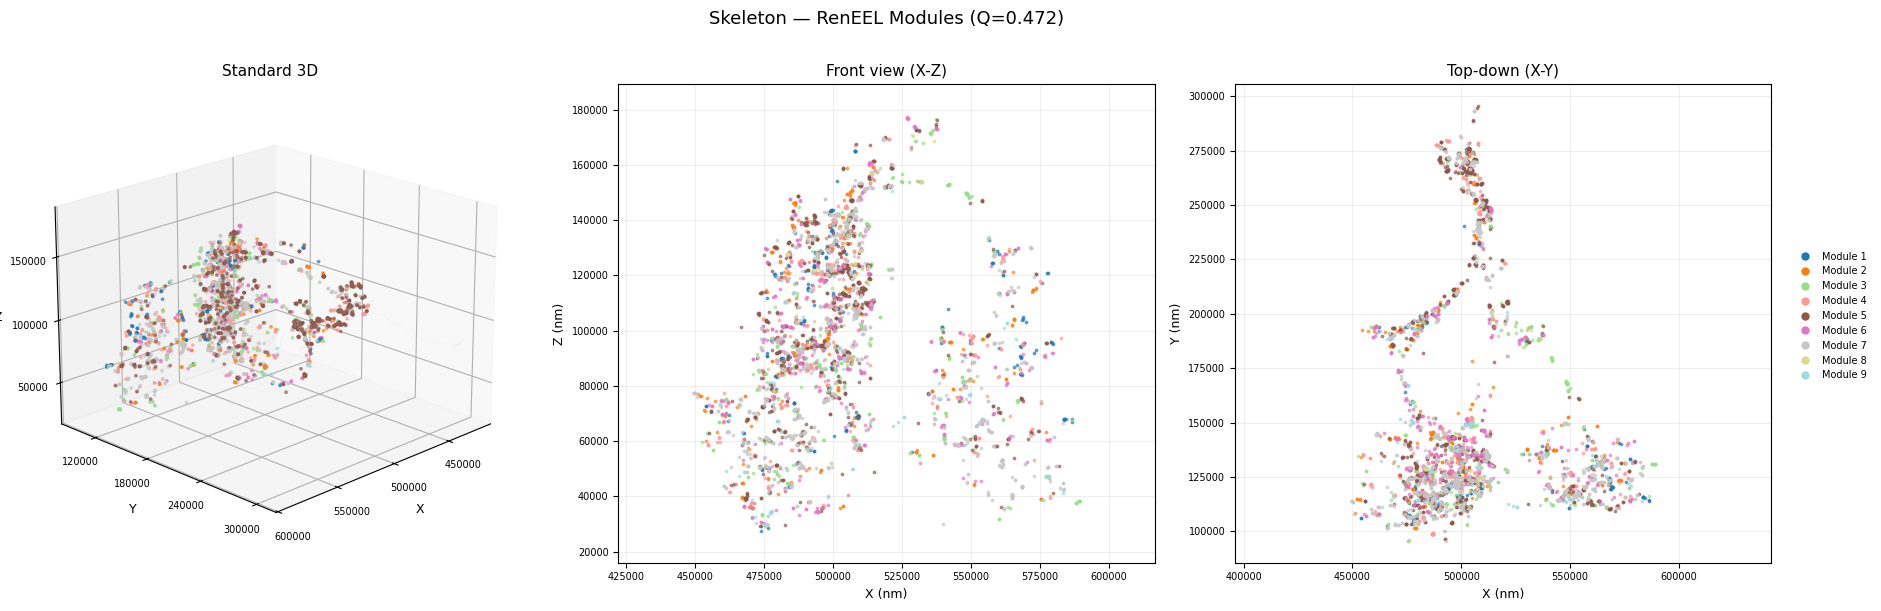

In [59]:
# ──────────────────────────────────────────────────────────
# CELL 9.2 — RenEEL on skeleton — 3 views
# ──────────────────────────────────────────────────────────
plot_multi_view(ovi_syns, reneel_partition, group_col='module',
                title_prefix=f'Skeleton — RenEEL Modules (Q={reneel_q:.3f})',
                skeleton_lines=skeleton_lines,
                save_path='skeleton_reneel_views.png')

Saved: skeleton_sbm_views.png


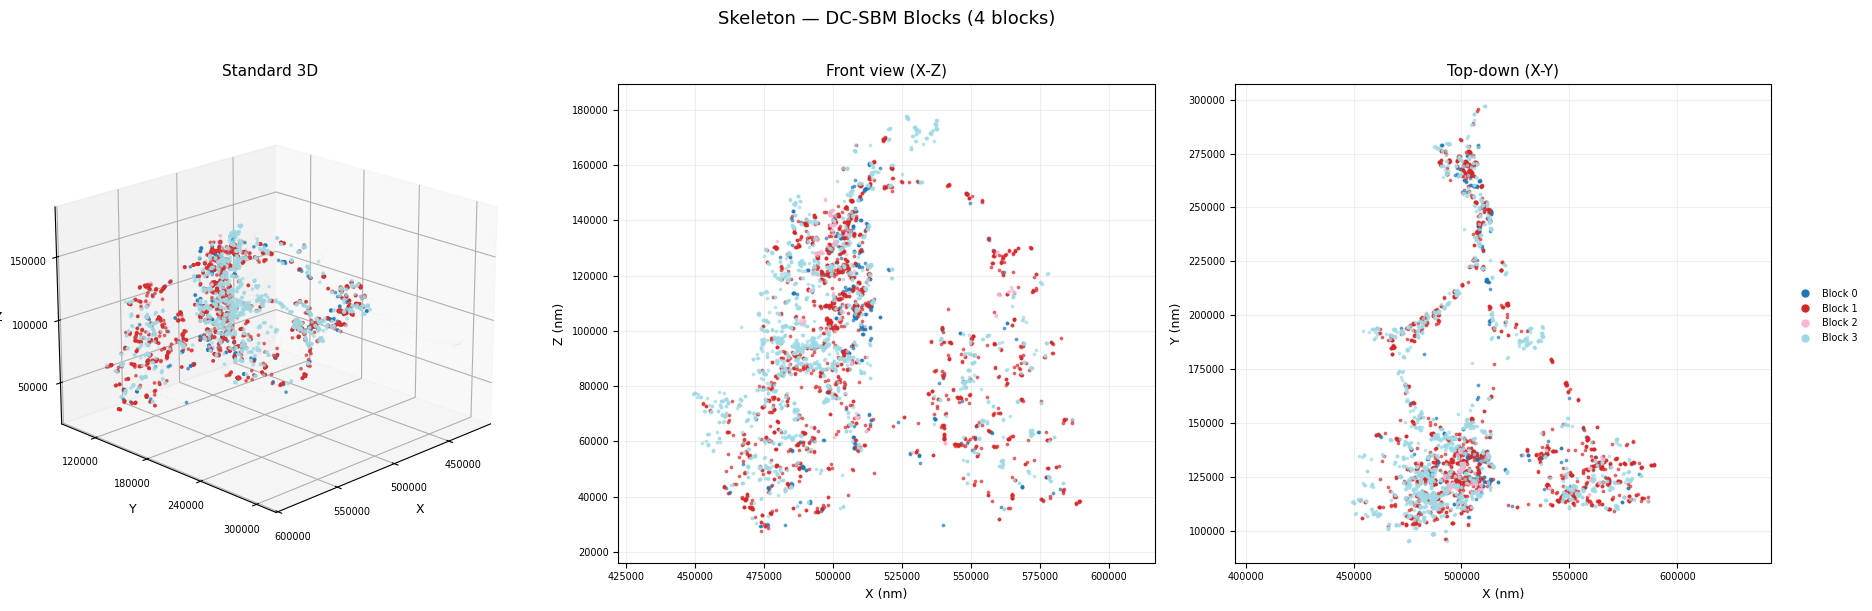

In [60]:
# ──────────────────────────────────────────────────────────
# CELL 9.3 — SBM on skeleton — 3 views
# ──────────────────────────────────────────────────────────
plot_multi_view(ovi_syns, sbm_partition, group_col='block',
                title_prefix=f'Skeleton — DC-SBM Blocks ({n_blocks} blocks)',
                skeleton_lines=skeleton_lines,
                save_path='skeleton_sbm_views.png')

## 9.4 Side-by-side front view (X-Z) for Hemibrain comparison

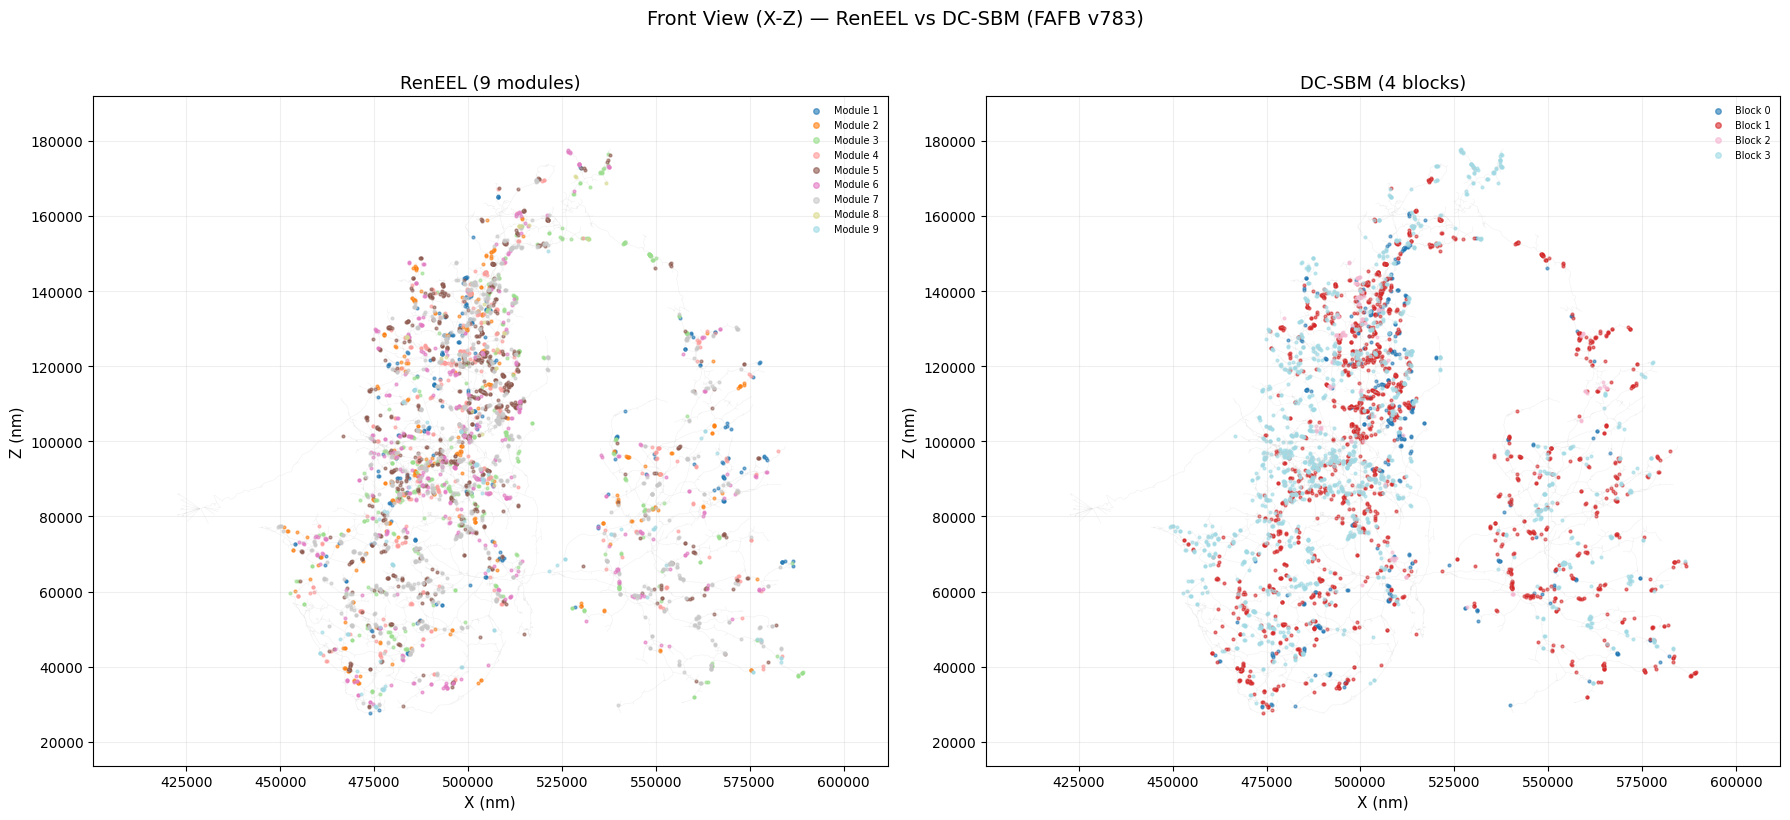

In [62]:
# ──────────────────────────────────────────────────────────
# CELL 9.4 — Side-by-side front view (X-Z) — 2D projection
# ──────────────────────────────────────────────────────────
import matplotlib.lines as mlines

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for ax, part, gcol, title in [
    (ax1, reneel_partition, 'module', f'RenEEL ({n_modules} modules)'),
    (ax2, sbm_partition, 'block', f'DC-SBM ({n_blocks} blocks)')
]:
    merged = ovi_syns.merge(part[['root_id', gcol]],
                            left_on='pre_pt_root_id', right_on='root_id', how='left')
    labeled = merged.dropna(subset=[gcol])
    n_g = int(labeled[gcol].nunique())
    cmap = plt.cm.get_cmap('tab20', max(n_g, 1))
    gvals = sorted(labeled[gcol].unique())

    # Draw skeleton as 2D line segments (X vs Z)
    if skeleton_lines is not None and len(skeleton_lines) > 0:
        from matplotlib.collections import LineCollection
        segs_2d = [[(p[0][0], p[0][2]), (p[1][0], p[1][2])] for p in skeleton_lines]
        lc = LineCollection(segs_2d, colors='lightgray', alpha=0.3, linewidths=0.4)
        ax.add_collection(lc)

    for gi, g in enumerate(gvals):
        mask = labeled[gcol] == g
        ax.scatter(labeled.loc[mask, 'post_x'],
                   labeled.loc[mask, 'post_z'],
                   c=[cmap(gi)], s=4, alpha=0.6,
                   label=f'{gcol.title()} {int(g)}')

    ax.set_xlabel('X (nm)', fontsize=11)
    ax.set_ylabel('Z (nm)', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, alpha=0.2)
    ax.autoscale()
    ax.legend(fontsize=7, frameon=False, markerscale=2,
              loc='upper right', bbox_to_anchor=(1.0, 1.0))

fig.suptitle('Front View (X-Z) — RenEEL vs DC-SBM (FAFB v783)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('skeleton_front_view.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure: Front view (X-Z) side-by-side comparison — RenEEL (9 modules) vs DC-SBM (4 blocks), FAFB v783.

This is the key comparison figure for direct visual comparison with the Hemibrain results. Both panels show the same anterior projection with X on the horizontal axis and Z (dorsal-ventral) on the vertical axis.

Left (RenEEL): The oviIN's dendritic structure is now clearly visible as a 2D silhouette. Three anatomical regions stand out: a dense central cluster around X=475,000–510,000 nm / Z=80,000–150,000 nm, an upper arm extending to Z=170,000+ nm, and a separate lateral cluster at X=530,000–585,000 nm. Colors are mixed throughout but show local clustering — neighboring synapses tend to share colors more than would be expected at random, consistent with partial spatial localization of modules on the dendrite.
Right (DC-SBM): The same three anatomical regions are visible, but the coloring is entirely different. Red (Block 1) and cyan (Block 3) are completely interleaved at every point in the morphology — the dense central cluster, the upper arm, and the lateral cluster all contain both colors in roughly equal proportions. There is no spatial boundary separating blocks anywhere in this projection.

The central visual result: Side by side at the same scale and orientation, the two methods tell fundamentally different stories about the same neuron. RenEEL finds communities that respect the neuron's spatial anatomy. The SBM finds communities that cut across it. This figure is the most direct evidence for the paper's central claim that the two methods are capturing different organizational principles — and it is now in the right format for comparison with the Hemibrain front view figures.